In [1]:
from backend.Agents.PDF_create import 

SyntaxError: invalid syntax (3619130629.py, line 1)

In [7]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\soumi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\soumi\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\soumi\AppData\Roaming\nltk_data...


True

In [15]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from selenium import webdriver
from rank_bm25 import BM25Okapi
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity
import requests
import trafilatura
from dotenv import load_dotenv
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
client = OpenAI()

def get_words_list(text: str):
    stop_words = set(ENGLISH_STOP_WORDS)
    lemmatizer = WordNetLemmatizer()

    # Fix merged words (camelCase → split)
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)

    # Separate numbers from words
    text = re.sub(r'(\d+)', r' \1 ', text)

    # Lowercase
    text = text.lower()

    # Extract words
    words = re.findall(r'\b[a-zA-Z]+\b', text)

    # Remove stopwords + lemmatize
    final_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return final_words

def keyword_score(sentence : str, body:str):
    sentence_list=get_words_list(sentence)

    body_word_list=get_words_list(body)
    sentence_set=set(sentence_list)
    score=0
    for a in body_word_list:
        if any(a.startswith(b) or b.startswith(a) for b in sentence_set):
            #checking prefix between a & b
            score+=1  

    final_score=score/len(body_word_list)

    return final_score 

def filter_list(query, A_dict_list):
    filtered_list=[]

    for a_dict in A_dict_list:

        body=a_dict.get('body')
        title=a_dict.get('title')

        score1=keyword_score(query, body)
        score2=keyword_score(query, title)

        score=0.95*score1+0.05*score2
        a_dict['keyword_score']=score
        
        if score>0.10:
            filtered_list.append(a_dict)

    filtered_list=sorted(filtered_list, key=lambda x: x['keyword_score'], reverse=True)
    return filtered_list


def get_html_content(url):
    headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}
    html=requests.get(url, headers=headers).text
    content=trafilatura.extract(html)

    if not content or len(content) < 150:
        driver = webdriver.Chrome()
        driver.get(url)
        html = driver.page_source
        content=trafilatura.extract(html)
        driver.quit()
    return str(content)

def chunk_text(text):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=300,       
        chunk_overlap=50,      
        separators=["\n\n", "\n", ".", " "]
    )
    
    chunks = splitter.split_text(text)
    return chunks


def bm25_retrieve(text:str, query:str):
    chunks = chunk_text(text)
    
    tokenized_corpus = [get_words_list(s) for s in chunks]
    
    bm25 = BM25Okapi(tokenized_corpus)
    
    tokenized_query = get_words_list(query)
    
    scores = bm25.get_scores(tokenized_query)
    
    # Rank sentences
    ranked = sorted(
        zip(chunks, scores),
        key=lambda x: x[1],
        reverse=True
    )
    ranked=ranked[:40]
    ranked_sentences=[sentence[0] for sentence in ranked]
    return ranked_sentences


def get_webpage(query:str, A_dict_list: list):

    filtered_list=filter_list(query=query, A_dict_list=A_dict_list)

    if len(filtered_list)>4:
        filtered_list=filtered_list[:4]

    web_content_chunks={}
    
    for filter in filtered_list:
        semantic_similar_sentence=[]
        website=str(filter.get('href'))
        
        content=get_html_content(website)

        sentences=bm25_retrieve(text=content, query=query)

        response = client.embeddings.create(
                model="text-embedding-3-small",
                input=[query] + sentences
                )
        
        embeddings = [item.embedding for item in response.data]
        query_embedding = embeddings[0]
        sentence_embeddings = embeddings[1:]
        scores = cosine_similarity([query_embedding], sentence_embeddings)[0]

        results = sorted(
            zip(sentences, scores),
            key=lambda x: x[1],
            reverse=True)
        
        web_content_chunks[website]=results[:7]

    
    return web_content_chunks
    


In [7]:
from backend.Agents.Search_Agent import search
query='What is the market rate of Gold Today in India'

A_dict_list=search(query)

In [10]:
a=get_webpage(query=query, A_dict_list=A_dict_list)

In [14]:
a

{'https://www.kalyanjewellers.net/kalyan_gold_rates/gold-rate/todays-gold-rate-in-karol-bagh': [('Discover the 22K gold rate in Delhi-Karol Bagh. Presenting you the latest updates on gold prices. Check out our gold price listings to find more.\n*Price may vary by city',
   np.float64(0.6034856971937813))],
 'https://www.prokerala.com/finance/gold-price.php?currency=INR': [("Live Gold Price in India • Indian Rupee\nToday's Gold Price in India = 14167.16996 INR / 1 Gram*\nLive Gold price in India on March 31 2026 stands at ₹13754.53 per gram for 22K gold and ₹14909.91 per gram for 24K gold in INR.",
   np.float64(0.7352927017499935)),
  ('The gold price today in India is ₹ 14167.17 per gram.\nThe average price for March 2026 is\n₹ 14399.14,\nshowing a lower trend compared to the March 2026 average of ₹ 14526.06.\nThe highest price for March 2026 reached ₹ 15569.88 , while the lowest was ₹12791.41 .',
   np.float64(0.7340484386581858)),
  ('Additionally, use the Currency Converter to esti

In [17]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
load_dotenv()

llm=ChatOpenAI(model='gpt-4o-mini')

response=llm.invoke([HumanMessage(content='Largest mammal')])

print(response.content)

The largest mammal on Earth is the blue whale (*Balaenoptera musculus*). Adult blue whales can grow to lengths of up to 100 feet (30 meters) or more and can weigh as much as 200 tons (approximately 181 metric tonnes) or more. They are known for their immense size, and their tongues alone can weigh as much as an elephant! Despite their size, blue whales primarily feed on small shrimp-like animals called krill.


In [19]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
load_dotenv()

llm=ChatOpenAI(model='gpt-5.4-mini')

response1=llm.invoke([HumanMessage(content='Largest mammal')])
print(response1.content)

The **largest mammal** is the **blue whale**.  

It’s the largest animal ever known to have lived on Earth, and adults can reach about **100 feet (30 meters)** long and weigh up to **200 tons (180 metric tonnes)** or more.


In [29]:
import os
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def send_email():
    sender="Soumil2433@gmail.com"
    app_password = os.getenv('GOOGLE_MAIL')

    to_email=['soumil.sinha18@gmail.com', 'educationmega@gmail.com']
    
    msg=MIMEMultipart()
    msg["From"] = sender
    msg["Subject"] = 'Test Email'

    msg.attach(MIMEText('Dear, Hello', 'plain'))
    
    all_recipients = to_email

    try:
        with smtplib.SMTP("smtp.gmail.com", 587) as server:
            server.starttls()
            server.login(sender, app_password)
            server.sendmail(sender, all_recipients, msg.as_string())
        return 'sent successfully'
    except Exception as e:
        return e

In [1]:
instruction = """You are an assistant responsible for composing professional emails based on user requests.

Your task is to:
- Identify the intent (e.g., announcement, notification, request).
- Extract key details such as date, purpose, and audience.
- Generate a clear, concise, and professional email.

Guidelines:
- Maintain a formal and informative tone.
- Ensure the message is suitable for a group audience.
- Include all necessary details (e.g., holiday date, reason if implied).
- Avoid unnecessary verbosity.
- Do not include placeholders unless information is missing.
- If required details are missing, make reasonable assumptions.

For the given request:
"Send an email to all the members informing them about the holiday on 5th April"

You should:
- Recognize this as an announcement email
- Clearly mention the holiday date (5th April)
- Address all members collectively
- Keep the message brief and professional"""

In [2]:
from langgraph.graph.state import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from backend.Agents.Common_State import State
from pydantic import BaseModel

new_state={
    'Email_Feedback': None,
    'body' : None,
    'LLM_instruction' : instruction,
    'messages' : 'Send a email to all the member informing them about the holiday on 5th April.'
}


graph=StateGraph(State)

In [3]:
from backend.Agents.Email_agent import Email_agent, review_node, send_email
from langgraph.checkpoint.memory import MemorySaver

graph.add_node("Email_agent", Email_agent)
graph.add_node("review", review_node)
graph.add_node("send_email", send_email)

graph.add_edge(START, "Email_agent")
graph.add_edge("Email_agent", "review")

checkpointer=MemorySaver()
final_graph=graph.compile(checkpointer=checkpointer)

In [4]:
config = {"configurable": {"thread_id": "thread-1"}}

result = final_graph.invoke(new_state, config=config)

In [5]:
from langgraph.types import Command
snapshot = final_graph.get_state(config)

# Now inspect what the LLM generated
print("Subject :", snapshot.values["subject"])
print("Body    :", snapshot.values["body"])

Subject : Announcement: Holiday on 5th April
Body    : Dear Members,

We would like to inform you that there will be a holiday on 5th April. Please make necessary arrangements and plan accordingly.

Thank you for your attention.

Best regards,
[Your Name]
[Your Position]


In [6]:
input='''Dear Members,

We would like to inform you that there will be a holiday on April 5th. Please take note of this date as our office will be closed.

Thank you for your attention.

Best regards,

Soumil Sinha'''

In [7]:
from langgraph.types import Command

human_feedback = {
    "subject": "Meeting Tomorrow at 10AM",  
    "body": input,
    "status": "approved",
    "sender" : "Soumil2433@gmail.com", 
    'to' : ['soumil.sinha18@gmail.com', 'soumil_s@ce.iitr.ac.in'],
    'cc' : ['educationmega@gmail.com'],
    'bcc' : ['soumilsinha571@gmail.com']
}

result = final_graph.invoke(
    Command(resume=human_feedback),
    config=config  # same thread_id — graph knows where it paused
)

In [1]:
from backend.Agents.Common_State import State
from backend.Agents.Search_Agent import Search_agent
from langgraph.graph.state import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


builder=StateGraph(State)

builder.add_node('search', Search_agent)

builder.add_edge(START, 'search')
builder.add_edge('search', END)

checkpointer1=MemorySaver()
graph=builder.compile(checkpointer=checkpointer1)

In [2]:
instruction1='''Interpret the user query and search for:
- Latest silver price in Delhi
- Prefer per gram and per kg
- Ensure data is recent (today/latest)
- Return only relevant financial information'''
state={
    'LLM_instruction' : instruction1
}

In [3]:
config = {"configurable": {"thread_id": "thread-2"}}

response=graph.invoke(state, config=config)

In [5]:
snapshot = graph.get_state(config)

In [11]:
search_result=snapshot.values['messages']
print(search_result[0].content)

As of the latest update, the silver price in Delhi is ₹242.71 per gram. For larger purchases, the price for one kilogram (1 kg) of silver is approximately ₹242,710. This reflects a slight decrease in price compared to other cities, such as Mumbai, where the silver rate is higher by about ₹0.41 per gram. 

Overall, the current silver rate in India is around ₹243.12 per gram, showing some variations across different locations.


In [1]:
from backend.Agents.PDF_create import PDF_Agent
from langgraph.graph.state import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from backend.Agents.Common_State import State

builder1=StateGraph(State)

builder1.add_node('pdf', PDF_Agent)

builder1.add_edge(START, 'pdf')
builder1.add_edge('pdf', END)

checkpointer2=MemorySaver()
graph1=builder1.compile(checkpointer=checkpointer2)

In [2]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage

new_state = {
    "LLM_instruction": "Generate a structured report from the given conversation and image.",
    
    "Last_PDF_Agent_output": "Initial draft of the report covering basic air quality insights.",
    
    "PDF_feedback": "Improve clarity, reduce repetition, and highlight key numerical trends.",
    
    "messages": [
        SystemMessage(content="You are an assistant that generates structured analytical reports."),
        
        HumanMessage(content="I have air quality data. Can you analyze it?"),
        AIMessage(content="Yes, please provide the dataset or details."),
        
        HumanMessage(content="The dataset shows PM2.5 values over 7 days."),
        AIMessage(content="Understood. I will look for trends and anomalies."),
        
        HumanMessage(content="The values are increasing gradually each day."),
        AIMessage(content="This suggests a worsening air quality trend."),
        
        HumanMessage(content="Can you summarize the trend briefly?"),
        AIMessage(content="PM2.5 levels show a consistent upward trend, indicating deteriorating air quality."),
        
        HumanMessage(content="Add possible reasons for this increase."),
        AIMessage(content="Possible reasons include increased vehicular emissions and weather conditions limiting dispersion."),
        
        HumanMessage(content="Make it more concise."),
        AIMessage(content="Air quality is worsening due to rising emissions and poor dispersion conditions."),
        
        HumanMessage(content="Now prepare a structured report."),
        AIMessage(content="Preparing a structured report with summary, causes, and observations.")
    ]
}

In [3]:
config = {"configurable": {"thread_id": "thread-3"}}

response=graph1.invoke(new_state, config=config)
snapshot = graph1.get_state(config)

In [4]:
pdf_base64=snapshot.values.get('pdf_base64')

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Air Quality Insights Report</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            line-height: 1.6;
            margin: 0;
            padding: 0;
            color: #333;
        }
        .overlay {
            position: fixed;
            top: 0;
            left: 0;
            width: 794px;
            height: 100%;
            background: rgba(255, 255, 255, 0.8);
            z-index: 1;
        }
        .content {
            position: relative;
            z-index: 2;
            padding: 80px 20px;
        }
        h1, h2, h3 {
            color: #2c3e50;
        }
        h1 {
            font-size: 24px;
            margin-bottom: 20px;
        }
        h2 {
            font-size: 20px;
            margin: 15px 0;
        }
        h3 {
            font-size: 18px;
            margin: 
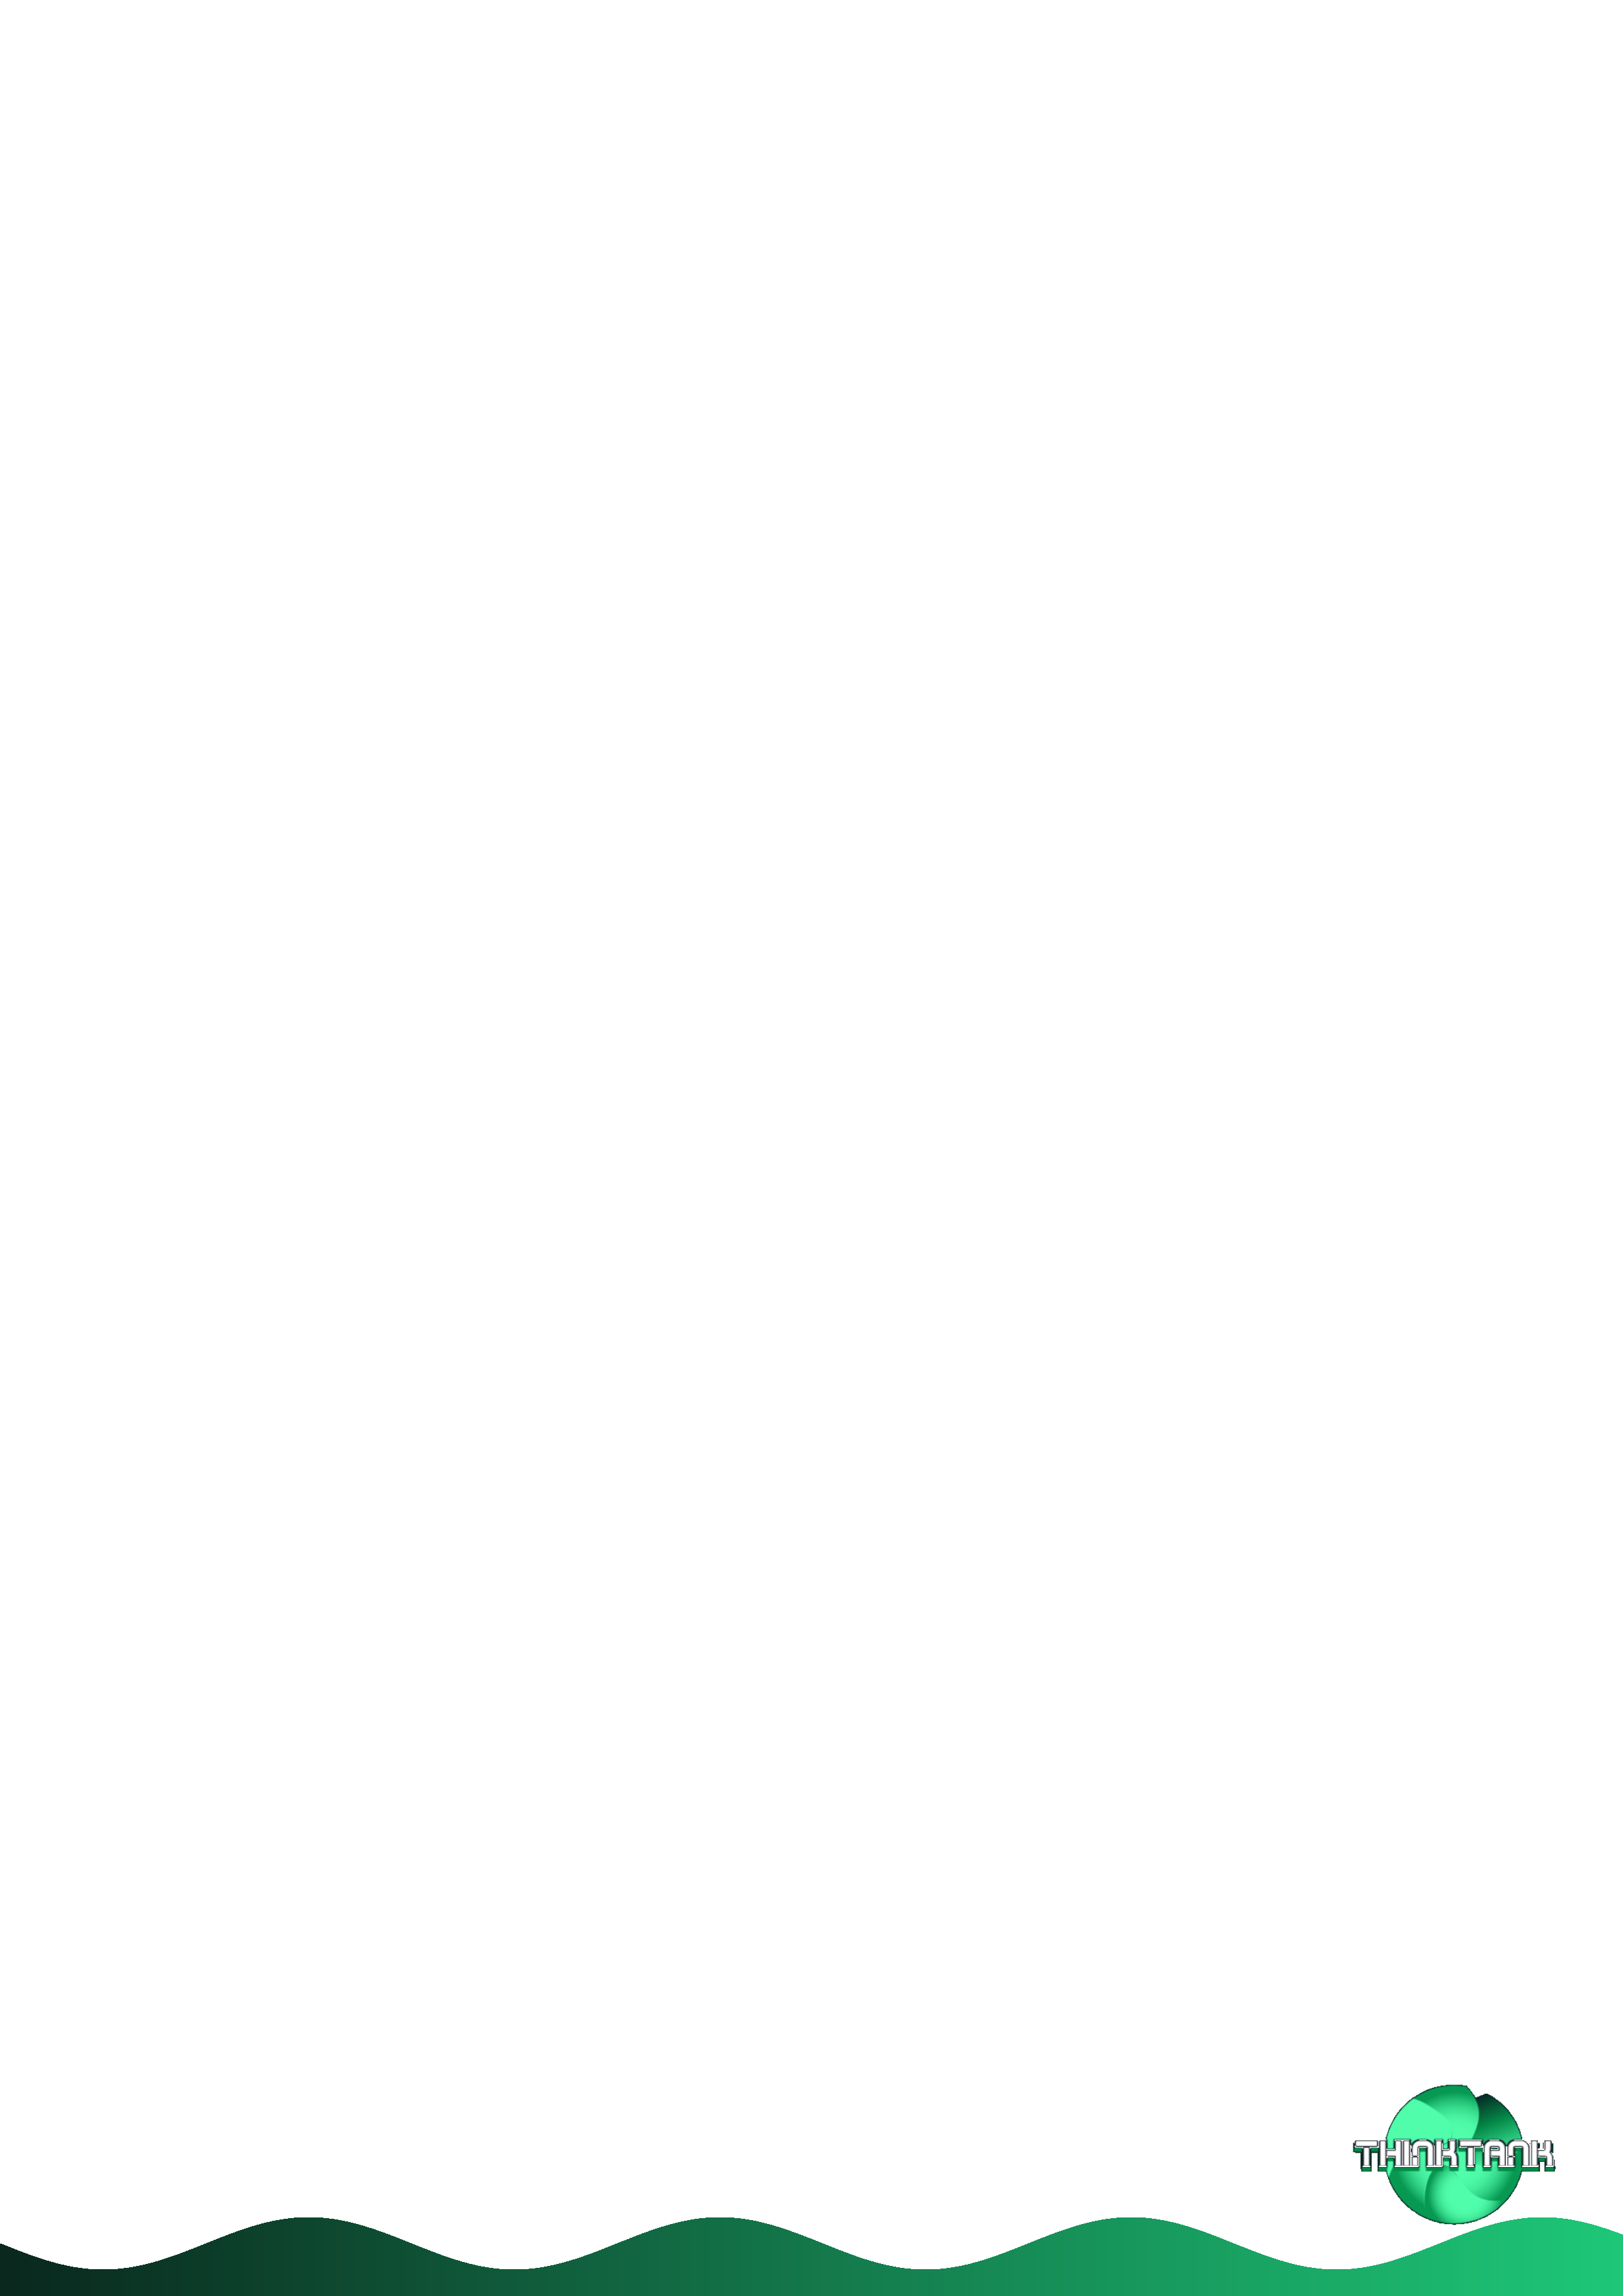

In [5]:
html=snapshot.values.get('pdf_html')
print(html)

In [6]:
import base64

def save_pdf_from_base64(pdf_base64: str, output_path: str = "output.pdf"):
    pdf_bytes = base64.b64decode(pdf_base64)
    
    with open(output_path, "wb") as f:
        f.write(pdf_bytes)

    print(f"PDF saved at {output_path}")

output="D:\After January\ThinkTank\Conversation_summary.pdf"
save_pdf_from_base64(pdf_base64=pdf_base64, output_path=output)

PDF saved at D:\After January\ThinkTank\Conversation_summary.pdf


<>:11: SyntaxWarning: invalid escape sequence '\A'
<>:11: SyntaxWarning: invalid escape sequence '\A'
C:\Users\soumi\AppData\Local\Temp\ipykernel_23400\3073011111.py:11: SyntaxWarning: invalid escape sequence '\A'
  output="D:\After January\ThinkTank\Conversation_summary.pdf"


In [ ]:
from typing import TypedDict, Annotated, cast
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, ToolMessage, SystemMessage
from backend.Agents.Common_State import State
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from datetime import datetime
import pdfkit
import shutil
import base64
import uuid
import os
import json
load_dotenv()

OPENAI_API_KEY=os.getenv('OPENAI_API_KEY')

llm=ChatOpenAI(api_key=OPENAI_API_KEY, model='gpt-4o-mini')

from pydantic import BaseModel, Field
from typing import List

class ActionItem(BaseModel):
    task: str
    responsible: str
    priority: str  # High / Medium / Low

class ChartData(BaseModel):
    label: str
    value: int  # percentage or count

class Insight(BaseModel):
    title: str                          = Field(description="Short punchy report title")
    tagline: str                        = Field(description="One line subtitle")
    final_decision: str                 = Field(description="What was ultimately concluded")
    key_ideas: List[str]                = Field(description="3-5 core ideas from the conversation")
    action_items: List[ActionItem]      = Field(description="Concrete tasks with owner and priority")
    risks: List[str]                    = Field(description="Risks and unresolved questions")
    insights: List[str]                 = Field(description="Key learnings and principles")
    agreements: List[str]               = Field(description="What was agreed upon")
    evolution: str                      = Field(description="How the conversation progressed")
    highlight_stat_1: ChartData         = Field(description="A key metric or percentage from the conversation e.g. 60% agreement")
    highlight_stat_2: ChartData         = Field(description="Another key metric or percentage")
    countdown_items: List[str]          = Field(description="4 sequential steps or phases derived from the action plan")

def extract_insights(state: State) -> Insight:
    structured_llm = llm.with_structured_output(Insight)
    response = structured_llm.invoke([
        SystemMessage(content="Extract structured insights from this conversation. Be concise and data-driven."),
        HumanMessage(content=conversation_text)
    ])
    return response


class Get_Html(BaseModel):
    html: str = Field(
        description=(
            "A complete, valid HTML document starting with <!DOCTYPE html>. "
            "Must contain all CSS inline or in a <style> block. "
            "Do NOT wrap in markdown code fences. "
            "Use BG_IMAGE_PLACEHOLDER as the CSS background-image value. "
            "The document must be directly renderable by wkhtmltopdf."
        )
    )

def image_to_base64(image_path: str) -> str:
    ext = os.path.splitext(image_path)[1].replace('.', '')
    with open(image_path, 'rb') as f:
        encoded = base64.b64encode(f.read()).decode('utf-8')
    return f"data:image/{ext};base64,{encoded}"


def Report(conversation : State, image_path : str='./pdf_image.png'):
    
    LLM_instruction = conversation['LLM_instruction']
    
    Last_Output=conversation.get('Last_PDF_Agent_output', '')
    feedback=conversation.get('PDF_feedback', "")
    conversation_text=''
    for message in conversation['messages']:
        if isinstance(message, HumanMessage):
            role = "human"
        elif isinstance(message, AIMessage):
            role = "assistant"
        elif isinstance(message, SystemMessage):
            role = "system"
        elif isinstance(message, ToolMessage):
            role = "tool"
        else:
            role = "unknown"
            
        conversation_text += f"{role}: {message.content}\n\n"

    image_b64=image_to_base64(image_path=image_path)

    instruction=f'''
You are an expert analyst and report generator.

Your task is to read a conversation between participants (which may include brainstorming, discussion, or idea exploration) and convert it into a structured, insight-rich report — NOT just a summary.

You must extract meaningful conclusions, reasoning, and actionable insights, then generate a clean HTML document that will later be converted into a PDF.
------------------------
FEEDBACK
------------------------
If there was a previous generation for this same task which was not satisfactory to the user, a feedback has been provided
Feedback : {feedback} for output : {Last_Output}
If the feedback is empty ignore it
------------------------
INPUT
------------------------
You will be given:
1. A list of messages (conversation)

------------------------
PART 1 — ANALYSIS
------------------------

Carefully analyze the conversation and extract:

1. Final Decision(s)
   - What was ultimately concluded?

2. Key Ideas & Concepts
   - Core idea
   - Supporting ideas
   - Variations explored

3. Argument Mapping
   - Main claims
   - Supporting reasoning
   - Counterarguments (if any)

4. Action Plan
   - Tasks
   - Responsible person (if mentioned)
   - Priority (High/Medium/Low)

5. Insights & Learnings
   - General principles or lessons derived

6. Risks & Gaps
   - Missing considerations
   - Potential risks
   - Unresolved questions

7. Agreements & Disagreements
   - What participants agreed on
   - What remained debated

8. Evolution of Thought (optional but preferred)
   - How the discussion progressed step-by-step

IMPORTANT RULES:
- Do NOT summarize line-by-line
- Focus on high-value insights and structure
- Be concise but meaningful
- Do NOT include raw conversation text unless necessary

------------------------
PART 2 — HTML GENERATION
------------------------

Generate a COMPLETE HTML document that presents the above analysis as a professional report.

STRICT REQUIREMENTS:

BACKGROUND IMAGE:
- Do NOT generate or include any image data yourself
- For the background, use this exact placeholder as the CSS value:
  background-image: BG_IMAGE_PLACEHOLDER;
- Apply it to a position:fixed full-page div with these styles:
  position: fixed; top: 0; left: 0; width: 794px; height: 100%;
  background-size: cover; background-repeat: no-repeat;
  background-position: center; z-index: -1;

- Page layout:
  - A4 width: 794px
  - Allow natural vertical flow (no fixed height)

- Spacing constraints:
  - Leave at least 80px space at the TOP (no content there)
  - Leave at least 80px space at the BOTTOM

- Add a semi-transparent overlay behind text to ensure readability over the background

- Typography:
  - Clean, modern, professional
  - Clear section hierarchy (headings, subheadings)

- Structure the report using sections:
  - Title (e.g., "Conversation Insight Report")
  - Date / metadata
  - Each analysis section clearly separated

- Use:
  - Headings (h1, h2, h3)
  - Bullet points where appropriate
  - Clean spacing and alignment

- The HTML must be directly usable with PDF tools (like wkhtmltopdf)

------------------------
OUTPUT RULES
------------------------

- Return ONLY valid HTML
- Do NOT include explanations
- Do NOT include markdown
- Do NOT include JSON
- Do NOT include any base64 image data
- Output must start with <!DOCTYPE html>

------------------------
GOAL
------------------------

Transform an unstructured conversation into:
→ a decision-ready report  
→ visually clean PDF-ready HTML  
→ insight-rich, structured output  

This is not summarization — this is intelligent analysis + presentation.
'''
    structure_llm=llm.with_structured_output(Get_Html)
    response=structure_llm.invoke([SystemMessage(content=instruction), AIMessage(content=LLM_instruction), HumanMessage(content=conversation_text)])
    html = response.html

    image_b64 = image_to_base64(image_path)
    html = html.replace("BG_IMAGE_PLACEHOLDER", f"url('{image_b64}')")


    options = {
        'page-size': 'A4',
        'margin-top': '0',
        'margin-right': '0',
        'margin-bottom': '0',
        'margin-left': '0',
        'encoding': 'UTF-8',
        'enable-local-file-access': '',
    }

    wkhtmltopdf_path = (
        os.getenv('WKHTMLTOPDF_PATH') or
        shutil.which('wkhtmltopdf') or
        r'C:\Program Files\wkhtmltopdf\bin\wkhtmltopdf.exe'
    )

    if wkhtmltopdf_path:
        config = pdfkit.configuration(wkhtmltopdf=wkhtmltopdf_path)
    else:
        config = None  # fallback (will still fail if not installed)

    pdf = cast(
        bytes,
        pdfkit.from_string(
            input=html,
            output_path=False,
            options=options,
            configuration=config))


    return pdf, html


def PDF_Agent(state: State):
    pdf_bytes, html = Report(conversation=state)
    pdf_base64 = base64.b64encode(pdf_bytes).decode("utf-8")
    return {
        "pdf_bytes": pdf_bytes,
        "pdf_base64": pdf_base64,
        "pdf_html" : html,
        "messages": [
            AIMessage(content="PDF generated. Please review.")
        ],
        'Last_PDF_Agent_output': html
        }


def review_pdf(state: State):
    response = interrupt({
        "type": "Review PDF",
        "pdf": state["pdf_base64"]
    })

    if isinstance(response, dict):
        decision = response.get("decision")
        feedback = response.get("feedback")
    else:
        decision = response
        feedback = None

    if decision == "approve":
        return Command(goto=END, update={'Last_PDF_Agent_output': None, 'pdf_bytes': None, 'pdf_feedback' : None})
    
    return Command(
        goto="PDF_Agent",
        update={"PDF_feedback": feedback}
    )


In [10]:
import requests
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv('TRELLO_API')
TOKEN = os.getenv('TRELLO_TOKEN')

def create_board(name):
    url = "https://api.trello.com/1/boards/"
    
    params = {
        "name": name,
        "defaultLists": "true",
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()




In [11]:
import requests
API_KEY = os.getenv('TRELLO_API')
TOKEN = os.getenv('TRELLO_TOKEN')

def get_boards():
    url = "https://api.trello.com/1/members/me/boards"
    
    params = {
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.get(url, params=params)
    return response.json()

a=get_boards()
print(a[1].get('id'))

69cf83b2f11c8e2110c23ce1


In [12]:
def create_list(board_id, list_name):
    url = "https://api.trello.com/1/lists"
    
    params = {
        "name": list_name,
        "idBoard": board_id,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

a=create_list('69cf83b2f11c8e2110c23ce1', 'Task Agent')
print(a)

def get_lists(board_id):
    url = f"https://api.trello.com/1/boards/{board_id}/lists"
    
    params = {
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.get(url, params=params)
    return response.json()


{'id': '69d0ea53b13b149ea4cc3de2', 'name': 'Task Agent', 'closed': False, 'color': None, 'idBoard': '69cf83b2f11c8e2110c23ce1', 'pos': 8192, 'type': None, 'datasource': {'filter': False}, 'limits': {}}


In [13]:
import requests

def create_card(list_id, title):
    url = "https://api.trello.com/1/cards"
    
    params = {
        "idList": list_id,
        "name": title,
        "key": API_KEY,
        "token": TOKEN
    }

    return requests.post(url, params=params).json()


# Example
card = create_card('69cf97021e5627a8d066ec8e', "Build API")
print(card)

{'id': '69d0ea5457cfbd937838a2a3', 'agent': {'name': None, 'conversationId': None}, 'badges': {'attachments': 0, 'fogbugz': '', 'checkItems': 0, 'checkItemsChecked': 0, 'checkItemsEarliestDue': None, 'comments': 0, 'description': False, 'due': None, 'dueComplete': False, 'lastUpdatedByAi': False, 'start': None, 'externalSource': None, 'attachmentsByType': {'trello': {'board': 0, 'card': 0}}, 'location': False, 'votes': 0, 'maliciousAttachments': 0, 'viewingMemberVoted': False, 'subscribed': False}, 'checkItemStates': [], 'closed': False, 'dueComplete': False, 'dateLastActivity': '2026-04-04T10:39:16.613Z', 'desc': '', 'descData': {'emoji': {}}, 'due': None, 'dueReminder': None, 'email': None, 'idBoard': '69cf94034149c2a00d877438', 'idChecklists': [], 'idList': '69cf97021e5627a8d066ec8e', 'idMembers': [], 'idMembersVoted': [], 'idShort': 2, 'idAttachmentCover': None, 'labels': [], 'idLabels': [], 'manualCoverAttachment': False, 'name': 'Build API', 'nodeId': 'ari:cloud:trello::card/work

In [14]:

BASE_URL = "https://api.trello.com/1"

def create_checklist(card_id, checklist_name):
    url = f"{BASE_URL}/checklists"
    
    params = {
        "idCard": card_id,
        "name": checklist_name,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

def add_checklist_item(checklist_id, item_name):
    url = f"{BASE_URL}/checklists/{checklist_id}/checkItems"
    
    params = {
        "name": item_name,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

In [15]:
import requests


def assign_member(card_id, member_id):
    url = f"https://api.trello.com/1/cards/{card_id}/idMembers"
    
    params = {
        "value": member_id,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()


In [ ]:
import requests

API_KEY = "your_api_key"
TOKEN = "your_token"

def set_due_date(card_id, due_date):
    url = f"https://api.trello.com/1/cards/{card_id}"
    
    params = {
        "due": due_date,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.put(url, params=params)
    return response.json()

{'id': '69cf98a416c9ec33283b5844', 'agent': {'name': None, 'conversationId': None}, 'badges': {'attachments': 0, 'fogbugz': '', 'checkItems': 0, 'checkItemsChecked': 0, 'checkItemsEarliestDue': None, 'comments': 0, 'description': False, 'due': None, 'dueComplete': False, 'lastUpdatedByAi': False, 'start': None, 'externalSource': None, 'attachmentsByType': {'trello': {'board': 0, 'card': 0}}, 'location': False, 'votes': 0, 'maliciousAttachments': 0, 'viewingMemberVoted': False, 'subscribed': False}, 'checkItemStates': [], 'closed': False, 'dueComplete': False, 'dateLastActivity': '2026-04-03T10:38:28.424Z', 'desc': '', 'descData': {'emoji': {}}, 'due': None, 'dueReminder': None, 'email': None, 'idBoard': '69cf94034149c2a00d877438', 'idChecklists': [], 'idList': '69cf97021e5627a8d066ec8e', 'idMembers': [], 'idMembersVoted': [], 'idShort': 1, 'idAttachmentCover': None, 'labels': [], 'idLabels': [], 'manualCoverAttachment': False, 'name': 'Build API', 'nodeId': 'ari:cloud:trello::card/work

In [8]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

new_state={
    'messages' : [

    SystemMessage(content="You are assisting a team in planning and launching a chatbot application project."),

    HumanMessage(content="Sahil : We should start by defining the backend architecture for the chatbot."),
    AIMessage(content="That’s a good starting point. Backend will handle APIs, data flow, and integrations."),

    HumanMessage(content="Soumil : From AI side, we need to decide whether to use an LLM API or fine-tune a model."),
    AIMessage(content="Using an API initially would speed up development and reduce infrastructure overhead."),

    HumanMessage(content="Soumya : From marketing perspective, we need to identify the target audience first."),
    AIMessage(content="Yes, defining user personas early will help shape both product and messaging."),

    HumanMessage(content="Owner : Let's align on the goal—this chatbot should help users with quick customer support."),
    AIMessage(content="Understood. So the chatbot will focus on customer support automation."),

    HumanMessage(content="Sahil : I can set up FastAPI endpoints for chatbot interaction."),
    AIMessage(content="That will provide a scalable backend interface for the chatbot."),

    HumanMessage(content="Soumil : I'll integrate the LLM and handle prompt design."),
    AIMessage(content="Prompt design will be critical for response quality."),

    HumanMessage(content="Soumya : We should also think about branding and positioning early."),
    AIMessage(content="Yes, early branding helps maintain consistency across product and marketing."),

    HumanMessage(content="Owner : Timeline is important. Can we aim for an MVP in 3 weeks?"),
    AIMessage(content="That seems feasible with clear task division and scope control."),

    HumanMessage(content="Sahil : I'll also handle database setup for storing conversations."),
    AIMessage(content="Conversation storage will help in analytics and improvements."),

    HumanMessage(content="Soumil : We may also add context memory for better responses."),
    AIMessage(content="Context memory will significantly improve user experience."),

    HumanMessage(content="Soumya : For launch, we should prepare a landing page."),
    AIMessage(content="A landing page will help capture early users and feedback."),

    HumanMessage(content="Owner : Let's divide into phases: backend, AI, and marketing."),
    AIMessage(content="Clear phases will streamline execution and tracking."),

    HumanMessage(content="Sahil : I’ll also ensure proper authentication and API security."),
    AIMessage(content="Security is essential, especially for user data protection."),

    HumanMessage(content="Soumil : I'll experiment with different prompts to optimize responses."),
    AIMessage(content="Iterative prompt tuning will improve chatbot performance."),

    HumanMessage(content="Soumya : We should create social media buzz before launch."),
    AIMessage(content="Pre-launch marketing can drive early adoption."),

    HumanMessage(content="Owner : Let’s also track KPIs like response accuracy and engagement."),
    AIMessage(content="Defining KPIs will help measure success effectively."),

    HumanMessage(content="Sahil : I’ll deploy backend using Docker and cloud services."),
    AIMessage(content="Containerization will make deployment scalable and manageable."),

    HumanMessage(content="Soumil : I can add fallback responses for unknown queries."),
    AIMessage(content="Fallback handling improves robustness of the chatbot."),

    HumanMessage(content="Soumya : We should collect user feedback post-launch."),
    AIMessage(content="Feedback loops are critical for iterative improvement."),

    HumanMessage(content="Owner : Good. Let’s schedule weekly check-ins."),
    AIMessage(content="Regular check-ins will ensure alignment across teams."),

    HumanMessage(content="Sahil : I’ll also set up logging for debugging."),
    AIMessage(content="Logging will help identify and resolve issues quickly."),

    HumanMessage(content="Soumil : I might explore fine-tuning later based on usage."),
    AIMessage(content="That would help customize the chatbot further."),

    HumanMessage(content="Soumya : I'll prepare email campaigns for launch."),
    AIMessage(content="Email campaigns can drive strong initial traction."),

    HumanMessage(content="Owner : Let's finalize responsibilities and start execution."),
    AIMessage(content="All roles are clear. The team is ready to begin execution.")
],

'members_list': [{'username' : 'soumil22', 'member_role': 'AI Engineer'}, {'username' : 'soumilsinha1', 'member_role': 'Backend Developer'},{'username' : 'soumil13', 'member_role': 'Marketing'},{'username' : 'soumilsinha18', 'member_role': 'Manager'}],
'board_name' : 'My Trello board'
}

In [9]:
from langgraph.graph.state import StateGraph, START, END
from backend.Agents.Common_State import State
from langgraph.checkpoint.memory import MemorySaver
from backend.Agents.Assign_task import Extract_tasks, Board_members_list, human_review, Trello_agent
from langgraph.types import Command, interrupt  
import uuid

builder=StateGraph(State)
builder.add_node('Assign_IDs', Board_members_list)
builder.add_node('Extract_Tasks', Extract_tasks)
builder.add_node('HITL', human_review)
builder.add_node('Trello', Trello_agent)

builder.add_edge(START, 'Assign_IDs')
builder.add_edge('Assign_IDs', 'Extract_Tasks')
builder.add_edge('Extract_Tasks', 'HITL')
builder.add_edge('Trello', END)

memory = MemorySaver()
graph=builder.compile(checkpointer=memory)

number=uuid.uuid4()
config = {"configurable": {"thread_id": str(number)}}

result_before = graph.invoke(new_state, config=config)


Assign members 1.4672858715057373
Extract tasks 31.667351245880127


In [10]:
snapshot=graph.get_state(config=config)

outline=snapshot.values
print(outline['board_outline'])

{'Board_name': 'My Trello board', 'lists': [{'name': 'Backend Phase', 'cards': [{'name': 'Define Backend Architecture', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': "Outline the technical specifications and components for the chatbot's backend.", 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Research best practices for backend architecture'}, {'name': 'Draft architecture diagram'}, {'name': 'Review architecture with team'}]}], 'due_date': '2026-04-07T18:00:00Z'}, {'name': 'Set Up FastAPI Endpoints', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Implement the FastAPI endpoints to facilitate interaction with the chatbot.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Create basic endpoint structure'}, {'name': 'Implement user interaction endpoint'}, {'name': 'Test API responses'}]}], 'due_date': '2026-04-09T18:00:00Z'}, {'name': 'Set Up Database for Conversations', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Establish a database to store and

In [12]:
command_input={'Board_name': 'My Trello board', 'lists': [{'name': 'Backend Development', 'cards': [{'name': 'Define Backend Architecture', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Outline the structure and components of the backend architecture for the chatbot.', 'checklists': [{'name': 'Steps to Define Backend Architecture', 'items': [{'name': 'Research existing chatbot architectures'}, {'name': 'Draft initial architecture diagram'}, {'name': 'Review with the team'}, {'name': 'Revise based on feedback'}, {'name': 'Document the final architecture'}]}], 'due_date': '2026-04-06T18:00:00Z'}, {'name': 'Set up FastAPI Endpoints', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Implement FastAPI endpoints to facilitate chatbot interactions.', 'checklists': [{'name': 'Steps to Set Up Endpoints', 'items': [{'name': 'Install FastAPI and dependencies'}, {'name': 'Create endpoint for user interaction'}, {'name': 'Test the endpoints'}, {'name': 'Document API usage'}, {'name': 'Prepare for deployment'}]}], 'due_date': '2026-04-10T18:00:00Z'}, {'name': 'Database Setup', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Create and configure a database for storing chatbot conversations.', 'checklists': [{'name': 'Steps for Database Setup', 'items': [{'name': 'Choose database technology'}, {'name': 'Design schema for conversations'}, {'name': 'Implement database setup script'}, {'name': 'Test database connections'}, {'name': 'Ensure data privacy compliance'}]}], 'due_date': '2026-04-09T18:00:00Z'}, {'name': 'Implement API Security', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Ensure the backend APIs are secure to protect user data.', 'checklists': [{'name': 'Steps for Implementing API Security', 'items': [{'name': 'Research best practices for API security'}, {'name': 'Implement authentication methods'}, {'name': 'Test security measures'}, {'name': 'Document security protocols'}, {'name': 'Monitor for vulnerabilities post-launch'}]}], 'due_date': '2026-04-12T18:00:00Z'}, {'name': 'Deploy Backend Using Docker', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Containerize the backend application for deployment.', 'checklists': [{'name': 'Steps to Deploy Backend', 'items': [{'name': 'Create Dockerfile for the backend'}, {'name': 'Build Docker image'}, {'name': 'Test the Docker image locally'}, {'name': 'Push image to cloud registry'}, {'name': 'Deploy on cloud service'}]}], 'due_date': '2026-04-15T18:00:00Z'}]}, {'name': 'AI Integration', 'cards': [{'name': 'Decide on LLM API or Fine-Tuning', 'assignee': '69cf84f1da7f09b64982e424', 'description': 'Select method for AI integration - use an LLM API or fine-tune an existing model.', 'checklists': [{'name': 'Steps to Decide AI Method', 'items': [{'name': 'Evaluate LLM API options'}, {'name': 'Assess requirements for fine-tuning'}, {'name': 'Discuss with the team'}, {'name': 'Make final decision'}, {'name': 'Document the choice'}]}], 'due_date': '2026-04-07T18:00:00Z'}, {'name': 'Integrate LLM and Design Prompts', 'assignee': '69cf84f1da7f09b64982e424', 'description': 'Incorporate the chosen LLM and design effective prompts.', 'checklists': [{'name': 'Steps for LLM Integration', 'items': [{'name': 'Set up LLM integration'}, {'name': 'Design initial prompts'}, {'name': 'Test prompts with sample inputs'}, {'name': 'Refine prompts based on performance'}, {'name': 'Document prompt implementation'}]}], 'due_date': '2026-04-11T18:00:00Z'}, {'name': 'Add Context Memory Feature', 'assignee': '69cf84f1da7f09b64982e424', 'description': 'Implement context memory to enhance response relevance.', 'checklists': [{'name': 'Steps to Add Context Memory', 'items': [{'name': 'Research context memory techniques'}, {'name': 'Develop memory structure'}, {'name': 'Integrate memory with existing system'}, {'name': 'Test for effectiveness'}, {'name': 'Documentation for future reference'}]}], 'due_date': '2026-04-14T18:00:00Z'}, {'name': 'Experiment with Prompts', 'assignee': '69cf84f1da7f09b64982e424', 'description': 'Optimize prompt responses through testing.', 'checklists': [{'name': 'Steps to Experiment with Prompts', 'items': [{'name': 'Create various prompt variations'}, {'name': "Test each version's response quality"}, {'name': 'Analyze results and performance'}, {'name': 'Refine prompts accordingly'}, {'name': 'Document findings for team reviews'}]}], 'due_date': '2026-04-13T18:00:00Z'}]}, {'name': 'Marketing Strategy', 'cards': [{'name': 'Identify Target Audience', 'assignee': '69cf839365a61a13925303b0', 'description': 'Determine user personas for the chatbot to shape product and marketing.', 'checklists': [{'name': 'Steps to Identify Target Audience', 'items': [{'name': 'Research potential user demographics'}, {'name': 'Create user persona profiles'}, {'name': 'Validate personas with team feedback'}, {'name': 'Adjust based on additional insights'}, {'name': 'Document final personas'}]}], 'due_date': '2026-04-08T18:00:00Z'}, {'name': 'Prepare Branding and Positioning', 'assignee': '69cf839365a61a13925303b0', 'description': 'Develop initial branding and positioning strategies for the product.', 'checklists': [{'name': 'Steps for Branding and Positioning', 'items': [{'name': "Research competitors' branding"}, {'name': 'Draft branding guidelines'}, {'name': 'Review branding with stakeholders'}, {'name': 'Finalize branding elements'}, {'name': 'Prepare brand launch strategy'}]}], 'due_date': '2026-04-10T18:00:00Z'}, {'name': 'Create Landing Page', 'assignee': '69cf839365a61a13925303b0', 'description': 'Design and build a landing page to capture early user interest.', 'checklists': [{'name': 'Steps to Create Landing Page', 'items': [{'name': 'Outline page content requirements'}, {'name': 'Design landing page layout'}, {'name': 'Develop landing page using HTML/CSS'}, {'name': 'Integrate feedback forms'}, {'name': 'Test page for functionality'}]}], 'due_date': '2026-04-12T18:00:00Z'}, {'name': 'Prepare Email Campaigns', 'assignee': '69cf839365a61a13925303b0', 'description': 'Draft and schedule email campaigns for launch promotion.', 'checklists': [{'name': 'Steps for Preparing Email Campaigns', 'items': [{'name': 'Draft email content'}, {'name': 'Create email distribution list'}, {'name': 'Schedule email sends'}, {'name': 'Test email templates'}, {'name': 'Analyze campaign performance post-launch'}]}], 'due_date': '2026-04-16T18:00:00Z'}, {'name': 'Create Social Media Buzz', 'assignee': '69cf839365a61a13925303b0', 'description': 'Plan and execute social media promotions leading up to the launch.', 'checklists': [{'name': 'Steps to Create Social Media Buzz', 'items': [{'name': 'Identify key social media platforms'}, {'name': 'Draft promotion posts'}, {'name': 'Schedule posts for maximum reach'}, {'name': 'Engage with audience pre-launch'}, {'name': 'Analyze engagement metrics post-launch'}]}], 'due_date': '2026-04-15T18:00:00Z'}]}]}
command_input12={'Board_name': 'My Trello board', 'lists': [{'name': 'Backend Phase', 'cards': [{'name': 'Define Backend Architecture', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': "Outline the technical specifications and components for the chatbot's backend.", 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Research best practices for backend architecture'}, {'name': 'Draft architecture diagram'}, {'name': 'Review architecture with team'}]}], 'due_date': '2026-04-07T18:00:00Z'}, {'name': 'Set Up FastAPI Endpoints', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Implement the FastAPI endpoints to facilitate interaction with the chatbot.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Create basic endpoint structure'}, {'name': 'Implement user interaction endpoint'}, {'name': 'Test API responses'}]}], 'due_date': '2026-04-09T18:00:00Z'}, {'name': 'Set Up Database for Conversations', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Establish a database to store and manage user conversations.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Choose suitable database technology'}, {'name': 'Design database schema'}, {'name': 'Set up database instance'}]}], 'due_date': '2026-04-09T18:00:00Z'}, {'name': 'Ensure Authentication and API Security', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Implement security measures to protect user data and API.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Research authentication methods'}, {'name': 'Integrate authentication framework'}, {'name': 'Perform security testing'}]}], 'due_date': '2026-04-10T18:00:00Z'}, {'name': 'Deploy Backend using Docker', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Use Docker to encapsulate the backend for scalable deployment.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Write Dockerfile'}, {'name': 'Build Docker image'}, {'name': 'Deploy container to cloud service'}]}], 'due_date': '2026-04-12T18:00:00Z'}, {'name': 'Log Setup for Debugging', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Implement logging strategy to monitor and debug backend operations.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Select logging framework'}, {'name': 'Integrate logging into services'}, {'name': 'Test logging functionality'}]}], 'due_date': '2026-04-12T18:00:00Z'}]}, {'name': 'AI Phase', 'cards': [{'name': 'Decide on LLM Approach', 'assignee': '69cf84f1da7f09b64982e424', 'description': 'Determine whether to use a third-party LLM API or fine-tune a model.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Evaluate LLM APIs available'}, {'name': 'Research fine-tuning options'}, {'name': 'Make a recommendation'}]}], 'due_date': '2026-04-08T18:00:00Z'}, {'name': 'Integrate LLM and Design Prompts', 'assignee': '69cf84f1da7f09b64982e424', 'description': 'Incorporate selected LLM and structure prompts for optimal responses.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Create integration plan'}, {'name': 'Design initial prompts'}, {'name': 'Test prompt responses'}]}], 'due_date': '2026-04-11T18:00:00Z'}, {'name': 'Experiment with Prompt Optimization', 'assignee': '69cf84f1da7f09b64982e424', 'description': 'Conduct experiments to fine-tune prompts for better performance.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Identify key metrics for responses'}, {'name': 'Run prompt variations'}, {'name': 'Analyze outcomes'}]}], 'due_date': '2026-04-14T18:00:00Z'}, {'name': 'Implement Context Memory Feature', 'assignee': '69cf84f1da7f09b64982e424', 'description': "Add context memory to improve the chatbot's response quality.", 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Design context memory structure'}, {'name': 'Implement context memory logic'}, {'name': 'Test effectiveness of memory'}]}], 'due_date': '2026-04-13T18:00:00Z'}, {'name': 'Add Fallback Responses for Unknown Queries', 'assignee': '69cf84f1da7f09b64982e424', 'description': 'Create fallback responses to enhance chatbot robustness.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Design fallback response framework'}, {'name': 'Implement fallback response integration'}, {'name': 'Test fallback responses'}]}], 'due_date': '2026-04-14T18:00:00Z'}]}, {'name': 'Marketing Phase', 'cards': [{'name': 'Identify Target Audience', 'assignee': '69cf839365a61a13925303b0', 'description': 'Research and define the target audience for the chatbot.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Conduct market research'}, {'name': 'Define user personas'}, {'name': 'Compile findings into a report'}]}], 'due_date': '2026-04-06T18:00:00Z'}, {'name': 'Prepare Branding and Positioning Strategy', 'assignee': '69cf839365a61a13925303b0', 'description': "Develop a branding strategy aligned with the chatbot's objectives.", 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Draft branding guidelines'}, {'name': 'Create positioning statement'}, {'name': 'Review with team'}]}], 'due_date': '2026-04-08T18:00:00Z'}, {'name': 'Create Landing Page for Launch', 'assignee': '69cf839365a61a13925303b0', 'description': 'Design and develop a landing page to capture early users and feedback.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Design landing page layout'}, {'name': 'Develop landing page front-end'}, {'name': 'Test landing page functionality'}]}], 'due_date': '2026-04-11T18:00:00Z'}, {'name': 'Plan Social Media Marketing Campaign', 'assignee': '69cf839365a61a13925303b0', 'description': 'Draft a strategy to create buzz and audience engagement through social media.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Identify platforms for campaign'}, {'name': 'Create content schedule'}, {'name': 'Draft initial posts'}]}], 'due_date': '2026-04-12T18:00:00Z'}, {'name': 'Prepare Email Campaigns for Launch', 'assignee': '69cf839365a61a13925303b0', 'description': 'Develop email campaigns aimed at pre-launch audience engagement.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Draft email content'}, {'name': 'Design email templates'}, {'name': 'Compile email list'}]}], 'due_date': '2026-04-10T18:00:00Z'}]}]}


In [ ]:
from langgraph.types import Command, interrupt  

snapshot=graph.get_state(config=config)

outline=snapshot.values
print(outline['board_outline'])

human_feedback = {
    'Board_Outline' : command_input12,
    'status' : 'approved',
    'feedback' : 'ok'
}

result =graph.invoke(
    Command(resume=human_feedback),
    config=config  # same thread_id — graph knows where it paused
)

Trello Agent started
{'Board_name': 'My Trello board', 'lists': [{'name': 'Backend Phase', 'cards': [{'name': 'Define Backend Architecture', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': "Outline the technical specifications and components for the chatbot's backend.", 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Research best practices for backend architecture'}, {'name': 'Draft architecture diagram'}, {'name': 'Review architecture with team'}]}], 'due_date': '2026-04-07T18:00:00Z'}, {'name': 'Set Up FastAPI Endpoints', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Implement the FastAPI endpoints to facilitate interaction with the chatbot.', 'checklists': [{'name': 'Tasks', 'items': [{'name': 'Create basic endpoint structure'}, {'name': 'Implement user interaction endpoint'}, {'name': 'Test API responses'}]}], 'due_date': '2026-04-09T18:00:00Z'}, {'name': 'Set Up Database for Conversations', 'assignee': '69cf846dbd3b33c3cb13120b', 'description': 'Establish a 

In [6]:
result['board_id']

'69cf83b2f11c8e2110c23ce1'

In [6]:
from dotenv import load_dotenv
import os
import requests
load_dotenv()

API_KEY = os.getenv('TRELLO_API')
TOKEN = os.getenv('TRELLO_TOKEN')
def get_board_members(board_id):
    url = f"https://api.trello.com/1/boards/{board_id}/members"
    
    params = {
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.get(url, params=params)
    return response.json()

print(get_board_members('69cf83b2f11c8e2110c23ce1'))

[{'id': '69cf846dbd3b33c3cb13120b', 'fullName': 'Soumil Sinha', 'username': 'soumilsinha1'}, {'id': '69cf839365a61a13925303b0', 'fullName': 'Soumil', 'username': 'soumil13'}, {'id': '69cf84f1da7f09b64982e424', 'fullName': 'Soumil', 'username': 'soumil22'}, {'id': '69cf843b94fb6cb1283951a7', 'fullName': 'soumil.sinha18', 'username': 'soumilsinha18'}]


In [6]:


def create_list(board_id, list_name):
    url = "https://api.trello.com/1/lists"
    
    params = {
        "name": list_name,
        "idBoard": board_id,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

def create_card(list_id, title, description=""):
    url = "https://api.trello.com/1/cards"
    
    params = {
        "idList": list_id,
        "name": title,
        "desc": description,   # 👈 add description here
        "key": API_KEY,
        "token": TOKEN
    }

    return requests.post(url, params=params).json()


BASE_URL = "https://api.trello.com/1"

def create_checklist(card_id, checklist_name):
    url = f"{BASE_URL}/checklists"
    
    params = {
        "idCard": card_id,
        "name": checklist_name,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

def add_checklist_item(checklist_id, item_name):
    url = f"{BASE_URL}/checklists/{checklist_id}/checkItems"
    
    params = {
        "name": item_name,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

def assign_member(card_id, member_id):
    url = f"https://api.trello.com/1/cards/{card_id}/idMembers"
    
    params = {
        "value": member_id,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

def set_due_date(card_id, due_date):
    url = f"https://api.trello.com/1/cards/{card_id}"
    
    params = {
        "due": due_date,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.put(url, params=params)
    return response.json()


[{'id': '69cf846dbd3b33c3cb13120b', 'fullName': 'Soumil Sinha', 'username': 'soumilsinha1'}, {'id': '69cf839365a61a13925303b0', 'fullName': 'Soumil', 'username': 'soumil13'}, {'id': '69cf84f1da7f09b64982e424', 'fullName': 'Soumil', 'username': 'soumil22'}, {'id': '69cf843b94fb6cb1283951a7', 'fullName': 'soumil.sinha18', 'username': 'soumilsinha18'}]


In [9]:
def get_boards():
    url = "https://api.trello.com/1/members/me/boards"
    
    params = {
        "key": API_KEY,
        "token": TOKEN
    }

    return requests.get(url, params=params).json()

def get_board_id_by_name(name):
    boards = get_boards()
    
    for board in boards:
        if board["name"] == name:
            return board["id"]
    
    return None

print(get_board_id_by_name('My Trello board'))

69cf83b2f11c8e2110c23ce1


In [3]:
from backend.Agents.Assign_task import Board_members_list

state={
    'board_name' : 'My Trello board',
    'members_list': [{'username' : 'soumil22', 'member_role': 'AI Engineer'}, {'username' : 'soumilsinha1', 'member_role': 'Backend Developer'},{'username' : 'soumil13', 'member_role': 'Marketing'},{'username' : 'soumilsinha18', 'member_role': 'Manager'}]
}

name_graph=StateGraph(State)

name_graph.add_node('Board_member', Board_members_list)

name_graph.add_edge(START, 'Board_member')
name_graph.add_edge('Board_member', END)

graph_name=name_graph.compile()

result=graph_name.invoke(state)

NameError: name 'StateGraph' is not defined

In [18]:
print(result)

{'messages': [], 'board_name': 'My Trello board', 'board_id': '69cf83b2f11c8e2110c23ce1', 'members_list': [{'username': 'soumil22', 'member_role': 'AI Engineer', 'member_trello_id': ''}, {'username': 'soumilsinha1', 'member_role': 'Backend Developer', 'member_trello_id': ''}, {'username': 'soumil13', 'member_role': 'Marketing', 'member_trello_id': ''}, {'username': 'soumilsinha18', 'member_role': 'Manager', 'member_trello_id': ''}]}


In [2]:
Trello_lst=create_list(board_id='69cf83b2f11c8e2110c23ce1', list_name='lst_name')

In [3]:
Trello_list_id=Trello_lst.get('id')
print(Trello_list_id)

69d0f530cd5b4ff6c3f05f2c


In [4]:
Trello_card=create_card(Trello_list_id, 'Ai Anthropic')
print(Trello_card)

{'id': '69d0f534194038c629e3fa8f', 'agent': {'name': None, 'conversationId': None}, 'badges': {'attachments': 0, 'fogbugz': '', 'checkItems': 0, 'checkItemsChecked': 0, 'checkItemsEarliestDue': None, 'comments': 0, 'description': False, 'due': None, 'dueComplete': False, 'lastUpdatedByAi': False, 'start': None, 'externalSource': None, 'attachmentsByType': {'trello': {'board': 0, 'card': 0}}, 'location': False, 'votes': 0, 'maliciousAttachments': 0, 'viewingMemberVoted': False, 'subscribed': False}, 'checkItemStates': [], 'closed': False, 'dueComplete': False, 'dateLastActivity': '2026-04-04T11:25:40.825Z', 'desc': '', 'descData': {'emoji': {}}, 'due': None, 'dueReminder': None, 'email': None, 'idBoard': '69cf83b2f11c8e2110c23ce1', 'idChecklists': [], 'idList': '69d0f530cd5b4ff6c3f05f2c', 'idMembers': [], 'idMembersVoted': [], 'idShort': 13, 'idAttachmentCover': None, 'labels': [], 'idLabels': [], 'manualCoverAttachment': False, 'name': 'Ai Anthropic', 'nodeId': 'ari:cloud:trello::card/

In [7]:
import requests


def assign_member(card_id, member_id):
    url = f"https://api.trello.com/1/cards/{card_id}/idMembers"
    
    params = {
        "value": member_id,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()


In [8]:
a=assign_member('69d0fb20ba73f0a1e2584757', '69cf846dbd3b33c3cb13120b')
print(a)

[{'id': '69cf846dbd3b33c3cb13120b', 'activityBlocked': False, 'avatarHash': 'e3e0b1f9336d012d26f4ea71e36a64e0', 'avatarUrl': 'https://trello-members.s3.amazonaws.com/69cf846dbd3b33c3cb13120b/e3e0b1f9336d012d26f4ea71e36a64e0', 'fullName': 'Soumil Sinha', 'idMemberReferrer': '69cf839365a61a13925303b0', 'initials': 'SS', 'nonPublic': {}, 'nonPublicAvailable': True, 'username': 'soumilsinha1'}]


In [25]:

def set_due_date(card_id, due_date):
    url = f"https://api.trello.com/1/cards/{card_id}"
    
    params = {
        "due": due_date,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.put(url, params=params)
    return response.json()

b=set_due_date('69cf846dbd3b33c3cb13120b', '2026-04-07T18:00:00Z')

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
from backend.Agents.Meet_scheduler_agent import get_creds, SCOPES

creds=get_creds()

Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=384528838627-roijctb4micdh2lbhb49s5daj8qj7rnc.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A49913%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcalendar&state=dblT0OkwPPTfaUReJWFitbJeOPlCP2&code_challenge=F78cVtaaOtDJSep5JRfZ2-ZUYd74gWSXv5-RDB6CF0w&code_challenge_method=S256&access_type=offline


In [ ]:
def get_calendar_service():
    creds = None

    if os.path.exists('token.json'):
        creds = Credentials.from_authorized_user_file('token.json', SCOPES)

    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            flow = InstalledAppFlow.from_client_secrets_file('credentials.json', SCOPES)
            creds = flow.run_local_server(port=0)
        with open('token.json', 'w') as f:
            f.write(creds.to_json())

    return build('calendar', 'v3', credentials=creds)

In [3]:
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
import os

SCOPES = ['https://www.googleapis.com/auth/calendar']

def get_calendar_service():
    creds = None

    if os.path.exists('token.json'):
        creds = Credentials.from_authorized_user_file('token.json', SCOPES)

    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            flow = InstalledAppFlow.from_client_secrets_file('credentials.json', SCOPES)
            creds = flow.run_local_server(port=0)
        with open('token.json', 'w') as f:
            f.write(creds.to_json())

    return build('calendar', 'v3', credentials=creds)
a=get_calendar_service()

Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=384528838627-svtd318lhin9e6qad2qhc2uffc1foblv.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A53556%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcalendar&state=d84XgSuiJFIVp9Vx2bkvKTsYMzLJui&code_challenge=YeUUwDyLID8C8GyA4mwikGyaRtkCUlpL341p8E5H5qU&code_challenge_method=S256&access_type=offline


In [4]:
print(a)

In [1]:
from backend.Agents.Meet_scheduler_agent import Scheduler_Agent, create_meeting, review_meeting
from backend.Agents.Common_State import State
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph.state import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
import uuid

new_state={
    'LLM_instruction' : """Schedule a Google Meet with the following details:
- Title: Recruitment Finalization Meeting
- Date: 13th April 2026
- Time: 2:00 PM
- Duration: 30 minutes (default)
- Agenda: Finalize candidates to be recruited for the team
- Send calendar invites to all relevant attendees""",
     'messages' : [
    HumanMessage(
        content="Can you schedule a Google Meet on 13th April at 2 PM? The agenda is to finalize who to recruit for the team."
    )]
}
number=uuid.uuid4()
config_scheduler = {"configurable": {"thread_id": str(number)}}

builder=StateGraph(State)

builder.add_node('Schedule', Scheduler_Agent)
builder.add_node('create', create_meeting)
builder.add_node('HITL', review_meeting)

builder.add_edge(START, 'Schedule')
builder.add_edge('Schedule', 'create')
builder.add_edge('create', 'HITL')

checkpointer=MemorySaver()
graph=builder.compile(checkpointer=checkpointer)

response=graph.invoke(new_state, config_scheduler)

In [3]:
from langgraph.types import Command, interrupt  

snapshot=graph.get_state(config=config_scheduler)

outline=snapshot.values
print(outline)

{'messages': [HumanMessage(content='Can you schedule a Google Meet on 13th April at 2 PM? The agenda is to finalize who to recruit for the team.', additional_kwargs={}, response_metadata={}, id='9f638061-6e2b-4091-b980-8f1535c7da57')], 'LLM_instruction': 'Schedule a Google Meet with the following details:\n- Title: Recruitment Finalization Meeting\n- Date: 13th April 2026\n- Time: 2:00 PM\n- Duration: 30 minutes (default)\n- Agenda: Finalize candidates to be recruited for the team\n- Send calendar invites to all relevant attendees', 'Meet_dict': {'summary': 'Recruitment Finalization Meeting', 'duration_min': 30, 'start_date_time': '2026-04-13T14:00:00+05:30', 'end_date_time': '2026-04-13T14:30:00+05:30'}, 'Meet_link': 'https://meet.google.com/uyi-jzzf-pkk'}


In [ ]:
human_feedback = {
    'Board_Outline' : command_input12,
    'status' : 'approved',
    'feedback' : 'ok'
}

result =graph.invoke(
    Command(resume=human_feedback),
    config=config  # same thread_id — graph knows where it paused
)

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
state = {
    'messages' : [
HumanMessage(content="We want to build a product called ThinkTank where teams can brainstorm ideas with AI assistance."),

HumanMessage(content="The core idea is to let multiple users collaborate in real-time and have AI guide the discussion."),

HumanMessage(content="It should feel like a smart meeting room where AI listens and contributes insights."),

HumanMessage(content="We need to decide if this is more of a chat app or a structured workspace."),

HumanMessage(content="Maybe we combine both—chat for brainstorming and structured panels for insights."),

HumanMessage(content="AI should summarize discussions periodically so users don’t lose track."),

HumanMessage(content="Yes, and it should extract action items automatically from conversations."),

HumanMessage(content="We should also capture decisions made during brainstorming sessions."),

HumanMessage(content="How do we differentiate from tools like Slack or Notion?"),

HumanMessage(content="Our focus should be AI-first, not just communication."),

HumanMessage(content="AI should actively suggest ideas, not just summarize."),

HumanMessage(content="We could have different AI modes like creative, analytical, and critical thinking."),

HumanMessage(content="That would help teams switch between ideation and evaluation."),

HumanMessage(content="We should also visualize discussions into diagrams or charts."),

HumanMessage(content="Yes, like mind maps or idea clusters."),

HumanMessage(content="We need a way to prioritize ideas based on team feedback."),

HumanMessage(content="Voting or ranking system could work."),

HumanMessage(content="AI can detect which ideas are getting the most traction."),

HumanMessage(content="What about integrating market research into brainstorming?"),

HumanMessage(content="We can let AI fetch competitor insights when needed."),

HumanMessage(content="That means we need some controlled web search capability."),

HumanMessage(content="We should ensure the AI doesn’t overuse external data unnecessarily."),

HumanMessage(content="Another feature could be role-based brainstorming."),

HumanMessage(content="Like product manager view, developer view, marketing view?"),

HumanMessage(content="Exactly, AI can tailor responses based on roles."),

HumanMessage(content="We should also allow exporting sessions into reports."),

HumanMessage(content="PDF reports with insights, charts, and action plans would be great."),

HumanMessage(content="This could be very useful for startups and corporate teams."),

HumanMessage(content="We need to think about onboarding experience."),

HumanMessage(content="Maybe a guided first brainstorming session with AI prompts."),

HumanMessage(content="We should also consider privacy and data security."),

HumanMessage(content="Yes, companies will want control over their data."),

HumanMessage(content="What tech stack are we thinking for this?"),

HumanMessage(content="Frontend could be React, backend FastAPI."),

HumanMessage(content="AI layer could be modular so we can plug different models."),

HumanMessage(content="We should design it in a multi-agent architecture."),

HumanMessage(content="One agent for insights, one for reports, maybe one for validation."),

HumanMessage(content="We also need to handle long conversations efficiently."),

HumanMessage(content="Maybe summarize and compress context over time."),

HumanMessage(content="What about real-time collaboration challenges?"),

HumanMessage(content="We can use WebSockets for syncing messages across users."),

HumanMessage(content="Finally, we need to define the MVP."),

HumanMessage(content="MVP should include chat, AI insights, and report generation."),

HumanMessage(content="Yes, keep it simple but impactful for first version.")
    ]
}

In [ ]:
from backend.Agents.PDF_create import Agent1Output, Agent2Output

def Agent1(state:State):
    conversation_history = ''
    
    messages = state['messages']
    for message in messages:
        if isinstance(message, HumanMessage):
            conversation_history+= f"Role : Human, Content : {message.content}\n"
        if isinstance(message, AIMessage):
            conversation_history+= f"Role : Assistant, Content : {message.content}\n"
        if isinstance(message, SystemMessage):
            conversation_history+= f"Role : System , Content : {message.content}\n"
        if isinstance(message, ToolMessage):
            conversation_history+= f"Role : Tool Call, Content : {message.content}\n"
    
    prompt = '''
You are an Advanced Project Intelligence Agent AND a Visual Report Designer.

Your output will be converted into a VISUAL PDF REPORT — not an article.
This means EVERY section must have at least one chart or visual element.
A report without charts is UNACCEPTABLE.

---

CORE MISSION:

You have two jobs:
1. Extract and generate insights that go BEYOND the team's discussion
2. Make EVERY insight visually representable with data

If the conversation does not contain numerical data — SEARCH FOR IT.
If search does not find exact numbers — DERIVE reasonable estimates based on industry standards.
A report with no charts is a FAILURE.

---

MANDATORY CHART REQUIREMENTS:

Every category MUST have at least ONE insight with:
- data_points populated (minimum 3 data points)
- visualization assigned

You MUST produce charts for:

1. Market_insights
   → ALWAYS include market size over time (line_chart)
   → Search: "[product category] market size forecast [year]"
   → Example data_points: [{label: "2023", value: 18}, {label: "2024", value: 21}, ...]

2. Rival_companies
   → ALWAYS include competitor comparison (bar_chart)
   → Compare on: AI Features, Pricing Score, Market Share, User Rating
   → Search: "[competitor] user rating" or "[competitor] pricing"
   → Example data_points: [{label: "Slack", value: 6}, {label: "Notion", value: 5}, ...]

3. Monetization_strategies
   → ALWAYS include revenue model distribution (pie_chart)
   → Search: "[product type] SaaS monetization models"
   → Example data_points: [{label: "Freemium", value: 45}, {label: "Per Seat", value: 30}, ...]

4. Risks
   → ALWAYS include risk severity comparison (bar_chart)
   → Assign severity scores (1-10) to each risk identified
   → Example data_points: [{label: "Data Privacy", value: 9}, {label: "Competition", value: 7}, ...]

5. Growth_strategies
   → ALWAYS include growth channel effectiveness (bar_chart)
   → Search: "[product type] user acquisition channels"
   → Example data_points: [{label: "Webinars", value: 35}, {label: "SEO", value: 25}, ...]

6. Customer_insights
   → ALWAYS include user segment breakdown (pie_chart)
   → Example data_points: [{label: "Startups", value: 40}, {label: "Enterprise", value: 35}, ...]

7. Technical_insights
   → ALWAYS include tech stack comparison or performance scores (bar_chart)
   → Example data_points: [{label: "React", value: 8}, {label: "Vue", value: 7}, ...]

8. Priority_signals
   → ALWAYS include priority matrix as bar_chart
   → Assign priority scores (1-10) to each signal
   → Example data_points: [{label: "AI Features", value: 9}, {label: "Security", value: 8}, ...]

9. Action_items
   → ALWAYS include effort vs impact as bar_chart
   → Assign impact scores (1-10) to each action item
   → Example data_points: [{label: "Define MVP", value: 9}, {label: "Onboarding", value: 7}, ...]

10. Business_insights
    → ALWAYS include business model viability scores (bar_chart)
    → Assign viability scores (1-10) to each strategy
    → Example data_points: [{label: "Freemium", value: 8}, {label: "Enterprise", value: 7}, ...]

---

SEARCH TOOL INSTRUCTIONS:

You MUST search for real numbers. Use search_tool for:

1. Market size and growth data
   → "[product category] market size CAGR forecast"

2. Competitor ratings and pricing
   → "[competitor name] G2 rating" or "[competitor] pricing per seat"

3. User acquisition channels effectiveness
   → "SaaS user acquisition channels effectiveness statistics"

4. Industry monetization benchmarks
   → "[product type] SaaS freemium conversion rate"

5. Tech stack performance benchmarks
   → "React vs Vue performance benchmark 2025"

Make up to 5 search calls. Always integrate findings into data_points.
If exact numbers are not found, use industry-standard estimates and mark them as approximate.

---

DATA POINT RULES:

NEVER leave data_points as None if ANY of the following is true:
- You can find numbers via search
- You can derive scores based on the discussion (e.g. importance → score)
- You can estimate based on industry standards
- You can create a comparison across 3+ items

MINIMUM 3 data points per visualization.
MAXIMUM 7 data points per visualization (keep charts readable).

Values must be:
- Actual numbers (market size in $B)
- Scores out of 10 (feature scores, risk scores, priority scores)
- Percentages (market share, distribution)
- Counts (number of features, team size)

---

VISUALIZATION ASSIGNMENT RULES:

- line_chart → time series data, trends, growth projections
- bar_chart → comparisons between items, scores, rankings
- pie_chart → proportions, distributions, market share
- table → structured multi-attribute comparison (use sparingly)

NEVER assign visualization=None if data_points are present.
NEVER leave data_points=None if a comparison or ranking is possible.

---

EXTRACTION CATEGORIES:

For EACH category generate insights regardless of whether the team discussed it.
If the team discussed it — go deeper and add what they missed.
If the team did NOT discuss it — research and generate insights anyway.
Every category must have minimum 2 insights, with at least 1 containing chart data.

Categories:
- Business_insights
- Market_insights
- Technical_insights
- Risks
- Action_items
- Decisions
- Open_questions
- Customer_insights
- Rival_companies
- Monetization_strategies
- Growth_strategies
- Priority_signals
- Knowledge_gaps

---

INSIGHT QUALITY RULES:

Each insight must be:
- Specific and grounded in real data or the conversation
- Actionable — the team can do something with it
- Non-obvious — go one layer deeper than what was said

---

OUTPUT RULES:

- Return ONLY valid JSON matching the schema
- Every category must have at least 2 insights
- AT LEAST ONE insight per category MUST have data_points and visualization
- importance: low | medium | high
- Do NOT leave any category empty
- Do NOT leave data_points=None when scores or comparisons are possible

---
'''

    human_instruction = f'''
The team is currently discussing the following project. Analyze it deeply and generate comprehensive insights across ALL categories.

CONVERSATION:
{conversation_history}

INSTRUCTIONS:
- Use search_tool to research competitors, market data, and validate technical choices
- Do NOT limit yourself to only what was discussed
- Every category must be populated — research what the team didn't cover
- Surface insights the team hasn't thought of yet
'''
    
    OPENAI_API_KEY=os.getenv('OPENAI_API_KEY')

    llm=ChatOpenAI(model='gpt-4o-mini')
    llm_with_tool=llm.bind_tools([search_tool])
    llm_structure=llm_with_tool.with_structured_output(Agent1Output)

    response=llm_structure.invoke([SystemMessage(content=prompt), HumanMessage(content=human_instruction)])

    return {
        'Agent1Output':response
    }

Business_insights=[Insight(text='The collaborative brainstorming market is projected to grow significantly, with an expected CAGR of 15% between 2023 and 2028. This indicates a strong demand for innovative solutions like ThinkTank.', importance='high', supporting_points=['The rise of remote work has increased the need for effective collaboration tools.', 'Investing early in this growing market can yield substantial returns.'], data_points=[DataPoint(label='2023', value=2.5), DataPoint(label='2024', value=3.0), DataPoint(label='2025', value=3.5)], visualization=Visualization(type='line_chart', title='Collaborative Brainstorming Market Size Forecast'), chart_path='/charts/collaborative_brainstorming_market_size'), Insight(text='Defining clear value propositions for ThinkTank could help differentiate it from existing tools. Features like AI-driven insights and role-based interactions should be emphasized to attract users.', importance='medium', supporting_points=['Addressing the specific 

In [ ]:
a=Business_insights=[Insight(text='The collaborative brainstorming market is projected to grow significantly, with an expected CAGR of 15% between 2023 and 2028. This indicates a strong demand for innovative solutions like ThinkTank.', importance='high', supporting_points=['The rise of remote work has increased the need for effective collaboration tools.', 'Investing early in this growing market can yield substantial returns.'], data_points=[DataPoint(label='2023', value=2.5), DataPoint(label='2024', value=3.0), DataPoint(label='2025', value=3.5)], visualization=Visualization(type='line_chart', title='Collaborative Brainstorming Market Size Forecast'), chart_path='/charts/collaborative_brainstorming_market_size'), Insight(text='Defining clear value propositions for ThinkTank could help differentiate it from existing tools. Features like AI-driven insights and role-based interactions should be emphasized to attract users.', importance='medium', supporting_points=['Addressing the specific demands of different user roles can enhance user engagement.', 'AI-driven features can provide unique value compared to traditional platforms.'], data_points=None, visualization=None, chart_path=None)] Market_insights=[Insight(text='The AI-driven collaboration tool market is expected to reach $9 billion by 2025, indicating a strong opportunity for ThinkTank to capture market share.', importance='high', supporting_points=['Increased reliance on technology for collaboration drives investment in AI features.', 'Identifying target customers and tailoring marketing strategies will be crucial.'], data_points=[DataPoint(label='2023', value=5.0), DataPoint(label='2024', value=7.0), DataPoint(label='2025', value=9.0)], visualization=Visualization(type='line_chart', title='AI-Driven Collaboration Tool Market Size Forecast'), chart_path='/charts/ai_driven_collaboration_market_size'), Insight(text='Competitors like Miro and MURAL are focusing on allowing teams to visually map ideas, which signifies that ThinkTank should also prioritize visual data representation.', importance='medium', supporting_points=['Visual tools enhance creativity and help teams organize thoughts effectively.', 'Integrating visualization features can set ThinkTank apart from standard chat apps.'], data_points=None, visualization=None, chart_path=None)] Technical_insights=[Insight(text='Using React for frontend and FastAPI for backend aligns well with modern tech stacks, offering scalability and efficiency for real-time collaboration features.', importance='high', supporting_points=['React provides a responsive user interface for seamless user experience.', 'FastAPI supports asynchronous processing, crucial for real-time functionalities.'], data_points=None, visualization=None, chart_path=None), Insight(text='Implementing WebSockets for message synchronization is essential for ensuring real-time collaboration is effective, mitigating challenges with lag.', importance='medium', supporting_points=['WebSockets enable full-duplex communication, vital for conversation-heavy applications.', 'This technology enhances user experience during brainstorming sessions.'], data_points=None, visualization=None, chart_path=None)] Risks=[Insight(text='A primary risk involves data privacy and security, which is crucial given the multi-user collaborative nature of ThinkTank.', importance='high', supporting_points=['User data breaches could severely impact credibility and trust.', 'Implementing robust encryption and data handling protocols is essential.'], data_points=[DataPoint(label='Data Breach Risk', value=9.0), DataPoint(label='Reputation Damage', value=8.0), DataPoint(label='Regulatory Risks', value=7.0)], visualization=Visualization(type='bar_chart', title='Risk Severity Comparison'), chart_path='/charts/risk_severity'), Insight(text='Technical challenges in ensuring real-time performance can lead to user dissatisfaction and hinder engagement.', importance='medium', supporting_points=['Long wait times in collaborative environments can frustrate users.', 'Continuous stress-testing is necessary to mitigate these risks.'], data_points=[DataPoint(label='Performance Lag', value=8.0), DataPoint(label='System Downtime', value=6.0), DataPoint(label='Scalability Issues', value=7.0)], visualization=Visualization(type='bar_chart', title='Technical Risk Severity'), chart_path='/charts/technical_risk_severity')] Action_items=[Insight(text='Conduct a competitive analysis to identify features that will set ThinkTank apart from Slack and Notion.', importance='high', supporting_points=["Understanding competitors' strengths and weaknesses can inform product development strategies."], data_points=[DataPoint(label='Competitive Analysis', value=9.0), DataPoint(label='Feature Prioritization', value=8.0), DataPoint(label='Market Positioning', value=7.0)], visualization=Visualization(type='bar_chart', title='Action Item Impact vs Effort'), chart_path='/charts/action_item_impact_effort'), Insight(text='Develop a prototype for MVP that includes core features: chat, AI insights, and report generation to validate user interest.', importance='high', supporting_points=['A working prototype can attract early users and feedback for further iterations.'], data_points=[DataPoint(label='MVP Development', value=9.0), DataPoint(label='User Testing', value=7.0), DataPoint(label='Feedback Gathering', value=8.0)], visualization=Visualization(type='bar_chart', title='Impact of MVP Features'), chart_path='/charts/mvp_feature_impact')] Decisions=[Insight(text='Decided to prioritize AI integration as the main differentiator for ThinkTank, focusing on dynamic suggestions and insights during brainstorming sessions.', importance='high', supporting_points=['AI capabilities will create a more engaging user experience and encourage creativity.'], data_points=None, visualization=None, chart_path=None), Insight(text='Agreed on the necessity of role-based views to tailor user experiences and facilitate targeted brainstorming.', importance='medium', supporting_points=['Different stakeholders will need personalized insights for productive sessions.', 'Role-based thinking will likely enhance engagement and productivity.'], data_points=None, visualization=None, chart_path=None)] Open_questions=[Insight(text='What features can we add to enhance user onboarding and ensure users understand how to leverage AI effectively?', importance='medium', supporting_points=['Effective onboarding is crucial for user retention and satisfaction.', 'Utilizing guided sessions during the onboarding process may help.'], data_points=None, visualization=None, chart_path=None), Insight(text='How can we ensure that the AI does not overly rely on external data so users maintain control over their brainstorming process?', importance='high', supporting_points=['Striking a balance between AI input and user initiative is crucial for fostering creativity.', 'Clear guidelines will need to be established for AI data usage.'], data_points=None, visualization=None, chart_path=None)] Customer_insights=[Insight(text='Target customers for ThinkTank include startups and corporate teams seeking dynamic brainstorming solutions that integrate AI features.', importance='high', supporting_points=['Understanding customer personas will help in tailoring product features and marketing strategies.', 'AI-enhanced collaboration tools appeal to teams looking for productivity boosts.'], data_points=[DataPoint(label='Startups', value=40.0), DataPoint(label='Enterprise Teams', value=35.0), DataPoint(label='SMBs', value=25.0)], visualization=Visualization(type='pie_chart', title='Customer Segment Breakdown'), chart_path='/charts/customer_segment_breakdown'), Insight(text='User feedback indicates a strong desire for effective session documentation and actionable outputs from brainstorming sessions.', importance='medium', supporting_points=['Providing post-session documents will be key for maintaining value after meetings.'], data_points=None, visualization=None, chart_path=None)] Rival_companies=[Insight(text='Existing competitors such as Miro and MURAL offer strong visual collaboration tools, highlighting the need for differentiation through AI functionalities.', importance='high', supporting_points=['Focus on AI-driven features can set ThinkTank apart in a crowded market.', 'Understanding competitor offerings will inform unique value propositions.'], data_points=[DataPoint(label='Miro (User Rating)', value=8.0), DataPoint(label='MURAL (User Rating)', value=7.0), DataPoint(label='Notion (User Rating)', value=8.0)], visualization=Visualization(type='bar_chart', title='Competitor User Ratings'), chart_path='/charts/competitor_user_ratings'), Insight(text='Pricing strategies vary across competitors; for example, Miro starts at $8/month/user, and Notion at $4/month/user. Understanding pricing will aid in positioning ThinkTank.', importance='medium', supporting_points=['Competitive pricing will be vital for attracting initial users.', 'Setting the right pricing tier aligns with target customer demographics.'], data_points=[DataPoint(label='Miro Price', value=8.0), DataPoint(label='Notion Price', value=4.0), DataPoint(label='Slack Price', value=6.0)], visualization=Visualization(type='bar_chart', title='Competitor Pricing Comparison'), chart_path='/charts/competitor_pricing')] Monetization_strategies=[Insight(text='Implementing a subscription-based model could generate sustained revenue, with tiered pricing based on features utilized.', importance='high', supporting_points=['Recurring revenue models provide financial stability and predictable cash flow.', 'Offering different tiers can cater to varied customer segments.'], data_points=[DataPoint(label='Freemium Model', value=45.0), DataPoint(label='Per Seat Pricing', value=35.0), DataPoint(label='Flat Rate', value=20.0)], visualization=Visualization(type='pie_chart', title='Monetization Model Distribution'), chart_path='/charts/monetization_model_distribution'), Insight(text='Exploring partnerships with organizations for enterprise solutions could enhance revenue, providing tailored offerings to larger clients.', importance='medium', supporting_points=['Enterprise clients typically provide larger contracts and long-term stability.', 'Partnerships can accelerate market entry through established networks.'], data_points=None, visualization=None, chart_path=None)] Growth_strategies=[Insight(text='Focusing on SEO and content marketing strategies will enhance brand visibility and attract potential users organically.', importance='high', supporting_points=['Content-driven strategies can establish authority in the market and draw interest from target demographics.', 'Higher organic traffic can reduce acquisition costs.'], data_points=[DataPoint(label='SEO Impact', value=30.0), DataPoint(label='Content Marketing Impact', value=40.0), DataPoint(label='Social Media Advertising Impact', value=25.0)], visualization=Visualization(type='bar_chart', title='User Acquisition Channel Effectiveness'), chart_path='/charts/user_acquisition_channel_effectiveness'), Insight(text='Leveraging webinars and online workshops for demonstrations can generate leads and educate potential users about ThinkTank.', importance='medium', supporting_points=['Interactive content can engage audiences and demonstrate product value effectively.', 'Webinars can serve as a platform for Q&A, building trust with potential customers.'], data_points=None, visualization=None, chart_path=None)] Priority_signals=[Insight(text='AI features are a top priority, emphasizing the need for continuous development to stay ahead of competitors.', importance='high', supporting_points=['Investing in AI will drive innovation and user engagement during brainstorming sessions.', 'The unique focus on AI should inform marketing and product roadmap.'], data_points=[DataPoint(label='AI Features Priority', value=9.0), DataPoint(label='User Experience Priority', value=8.0), DataPoint(label='Security Priority', value=7.0)], visualization=Visualization(type='bar_chart', title='Priority Area Scores'), chart_path='/charts/priority_signal_scores'), Insight(text='User onboarding experience is crucial for user retention and satisfaction, indicating a need for focused strategies to guide new users.', importance='medium', supporting_points=['Effective onboarding helps users realize product value quickly, enhancing retention rates.', 'Initial user experience can have lasting effects on user perception.'], data_points=[DataPoint(label='Onboarding Experience Priority', value=8.0), DataPoint(label='Feature Utilization Priority', value=7.0), DataPoint(label='User Feedback Priority', value=8.0)], visualization=Visualization(type='bar_chart', title='User Onboarding Priority Scores'), chart_path='/charts/user_onboarding_priority_scores')] Knowledge_gaps=[Insight(text='Further exploration is needed to ascertain specific customer pain points related to brainstorming tools.', importance='high', supporting_points=['Direct user interviews and surveys will help refine product features to meet market needs.', 'Understanding pain points could drive feature prioritization and development.'], data_points=None, visualization=None, chart_path=None), Insight(text='Determine how potential users perceive the integration of AI within collaboration tools, especially in terms of value addition.', importance='medium', supporting_points=['User attitudes toward AI can heavily influence adoption rates.', 'Gathering insights on user biases can inform AI feature development.'], data_points=None, visualization=None, chart_path=None)]
c=a.model_dump()

<class 'dict'>
True
{'pdf_html': '<!DOCTYPE html>\n<html lang="en">\n<head>\n    <meta charset="UTF-8">\n    <meta name="viewport" content="width=device-width, initial-scale=1.0">\n    <title>Professional Report</title>\n    <style>\n        body {\n            \n            background-size: cover;\n            background-repeat: no-repeat;\n            background-attachment: fixed;\n        }\n        .background-fixed {\n            position:fixed;\n            top:0;\n            left:0;\n            width:100%;\n            height:100%;\n            \n            background-size:cover;\n            background-repeat:no-repeat;\n            z-index:-1;\n        }\n        h1, h2, h3 {\n            color: #1a472a;\n        }\n        header {\n            background-color: #1a472a;\n            color: #ffffff;\n            padding: 80px 50px;\n            text-align: center;\n        }\n        section {\n            background: rgba(255, 255, 255, 0.93);\n            border-radius: 
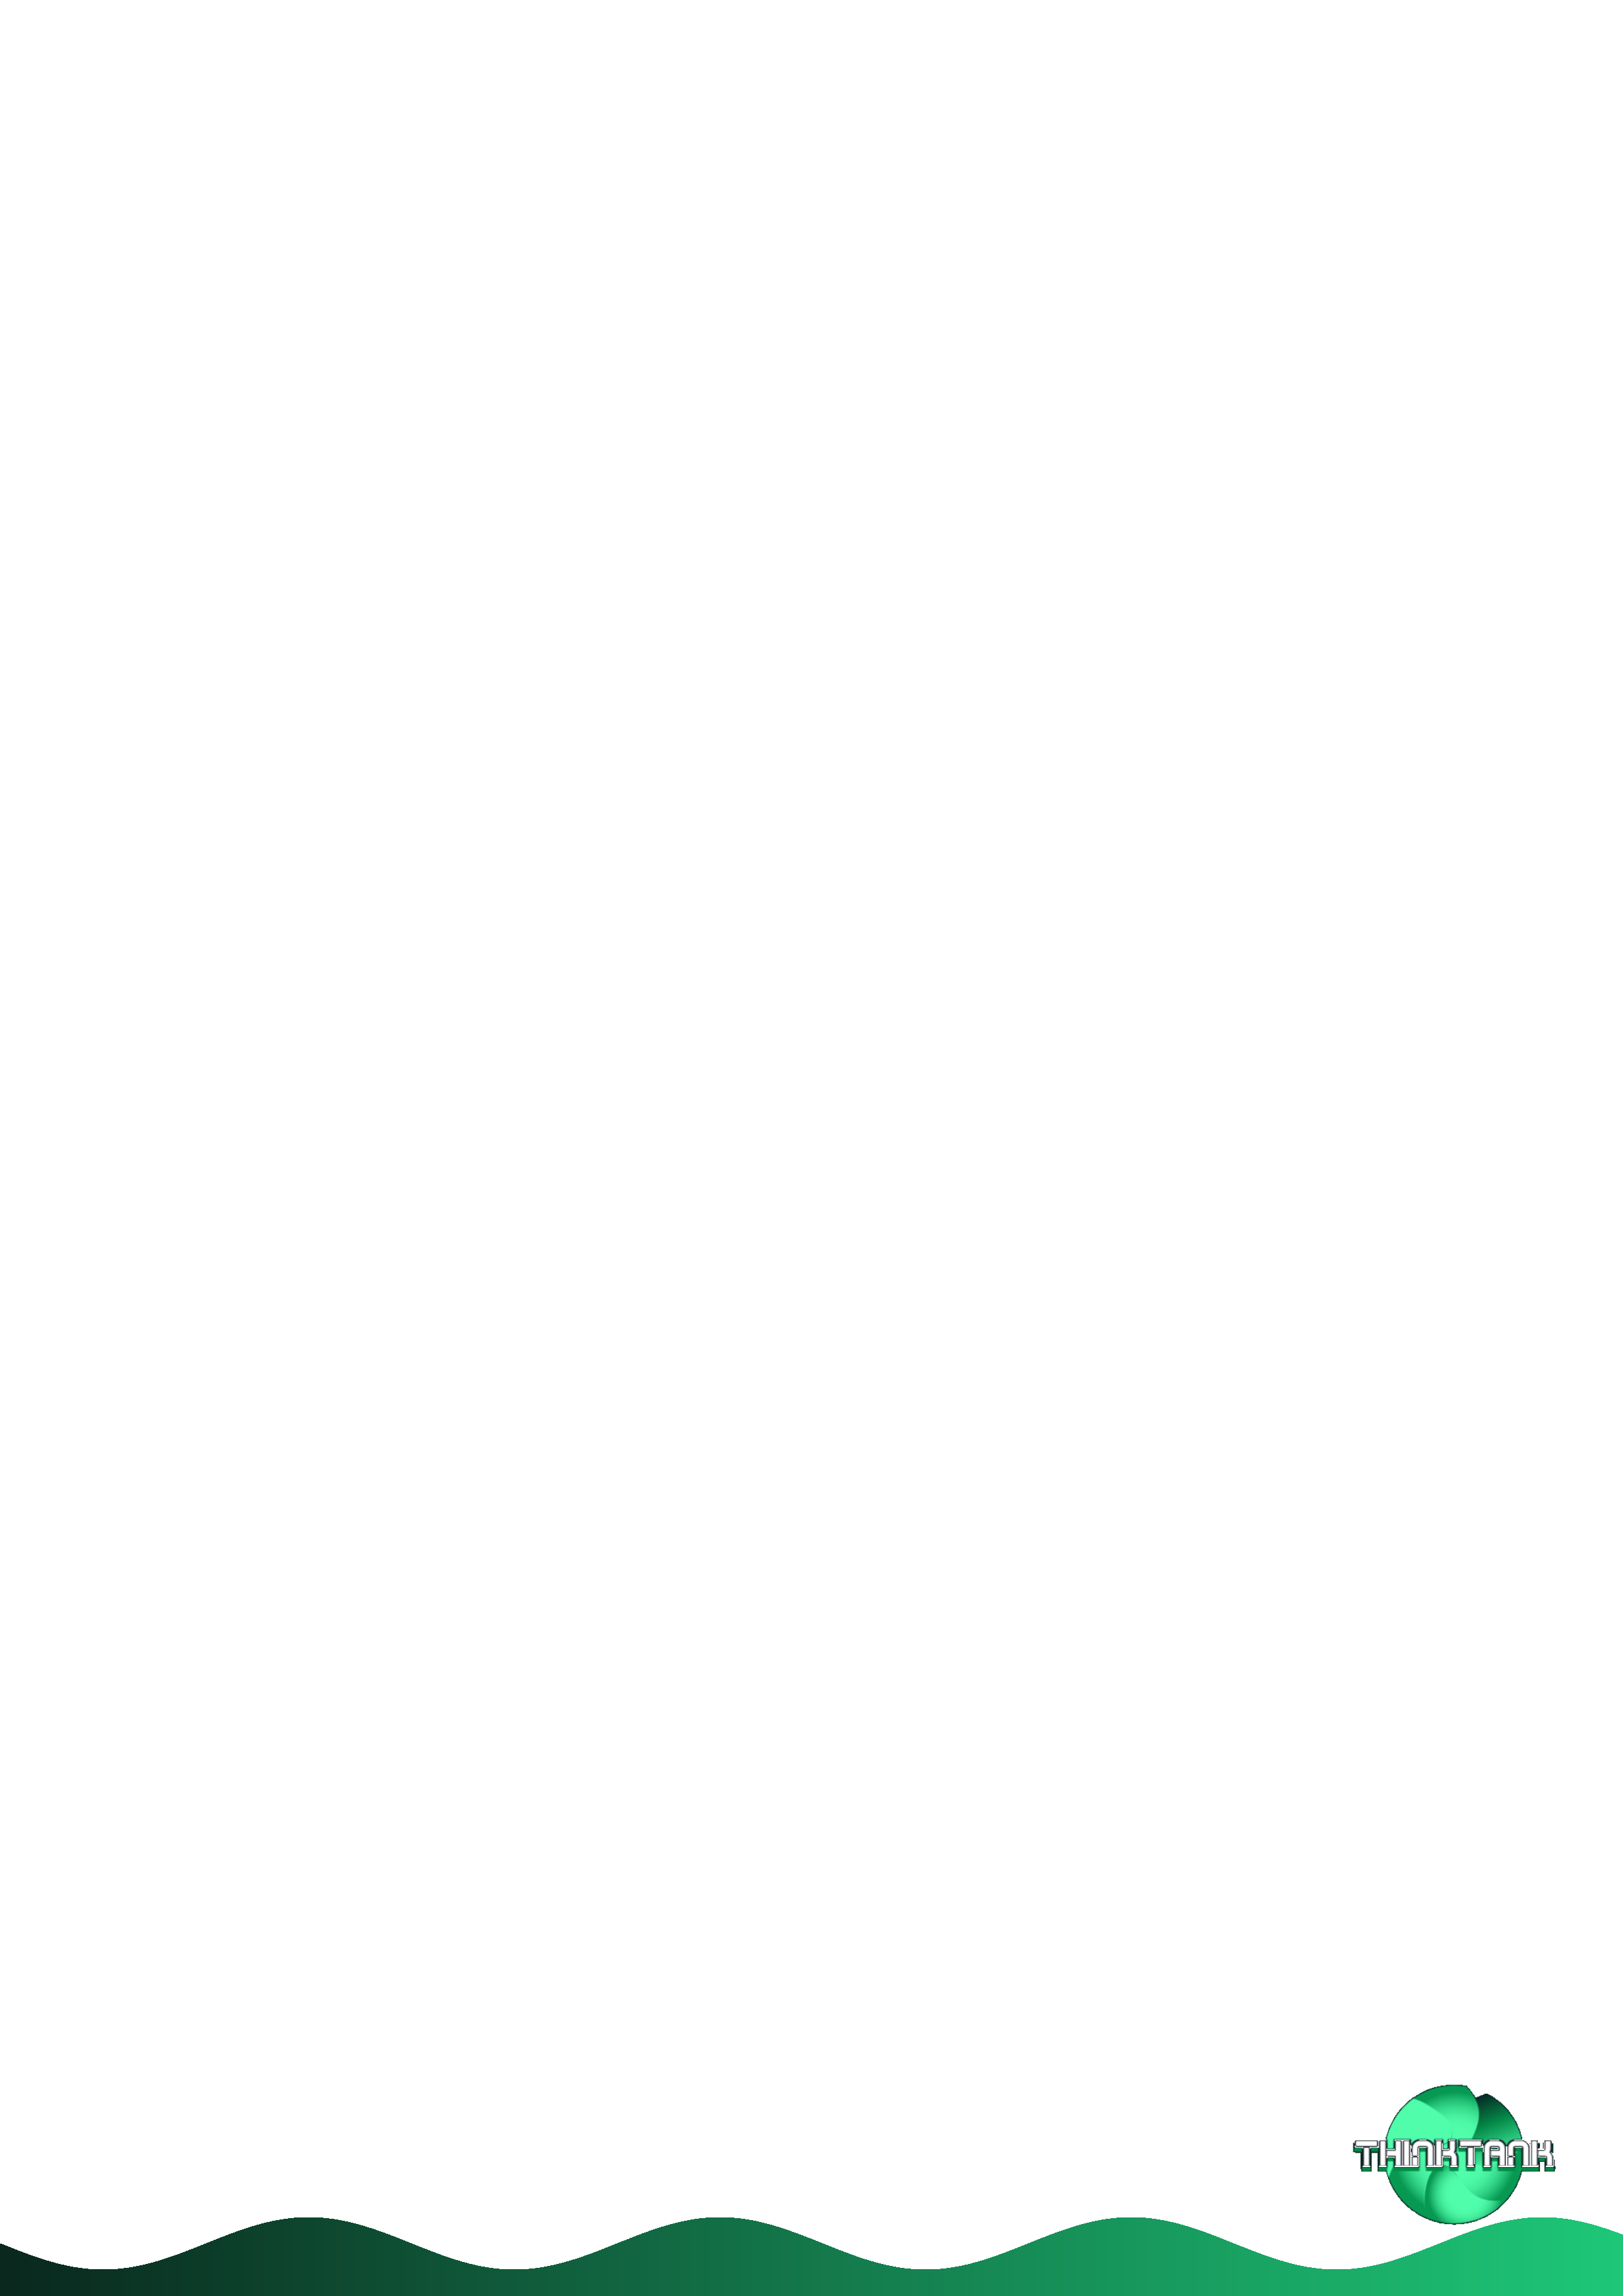
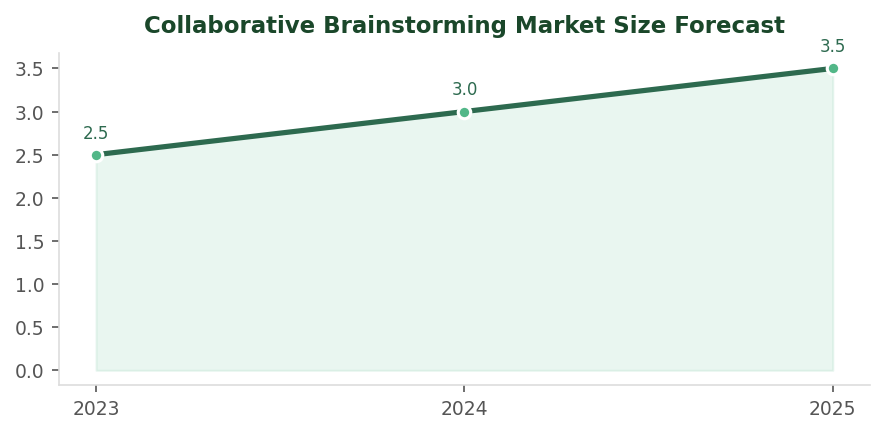
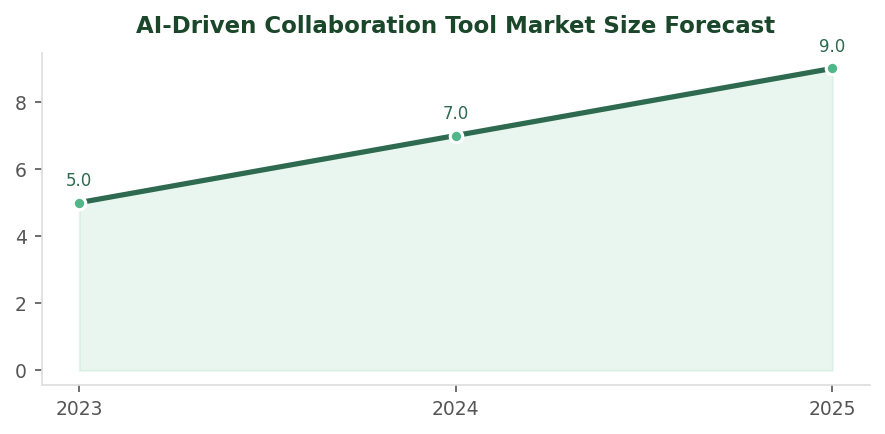
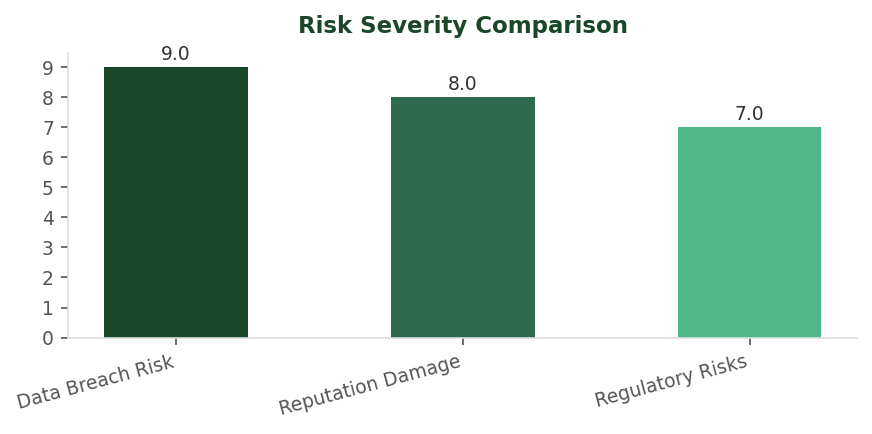
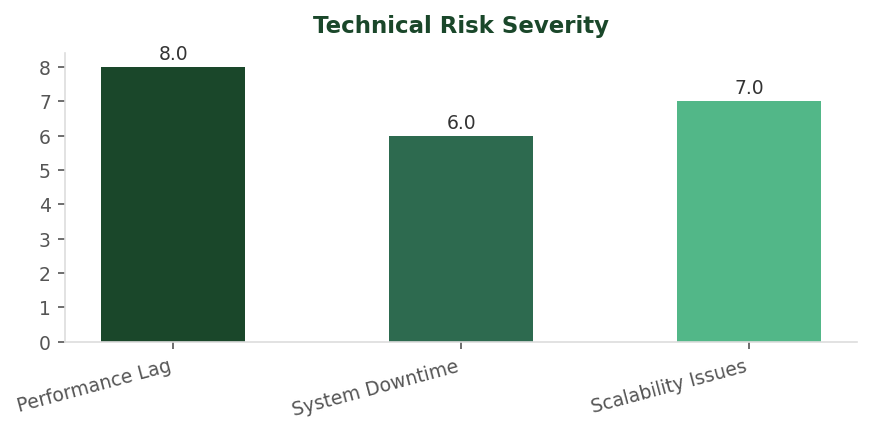
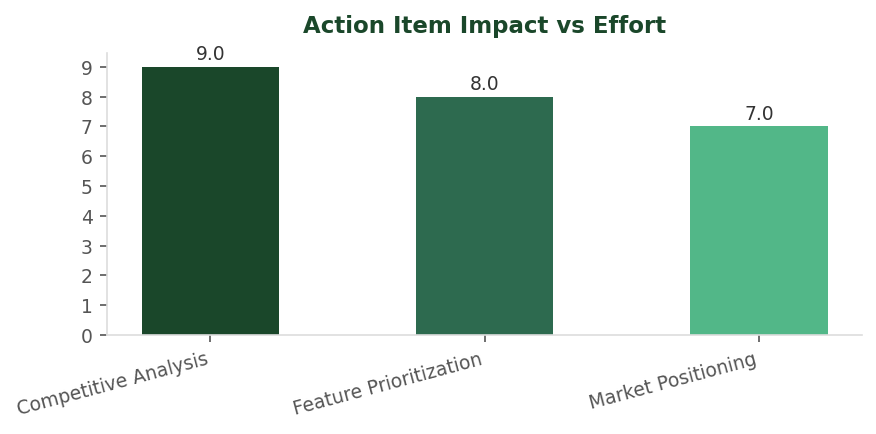
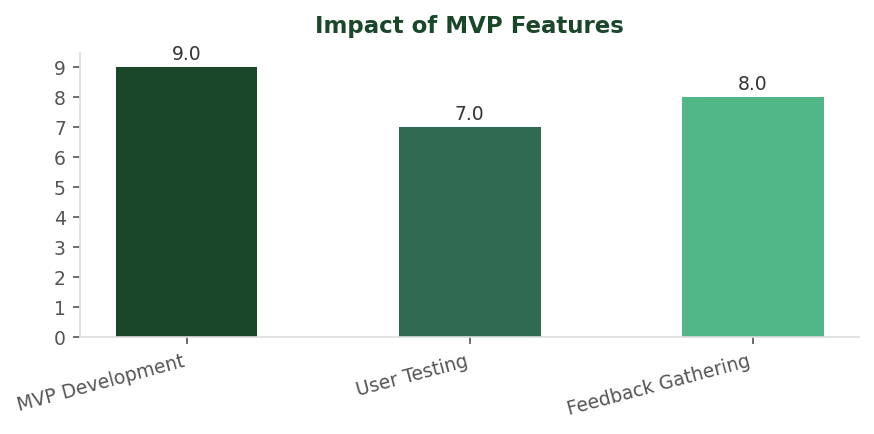
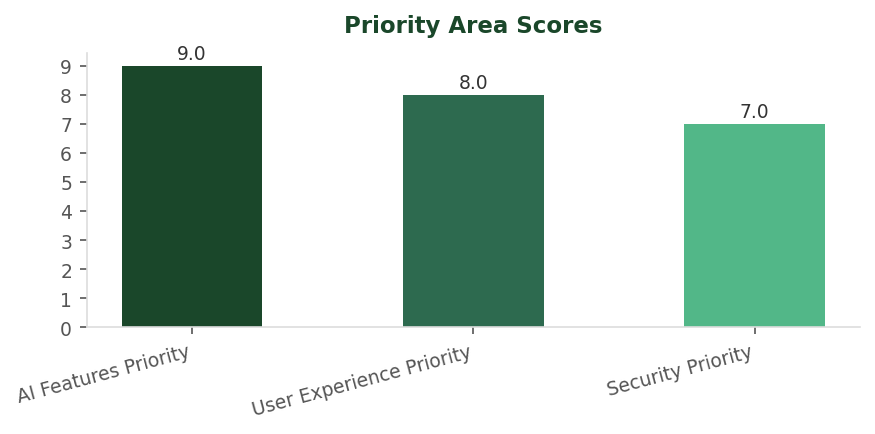
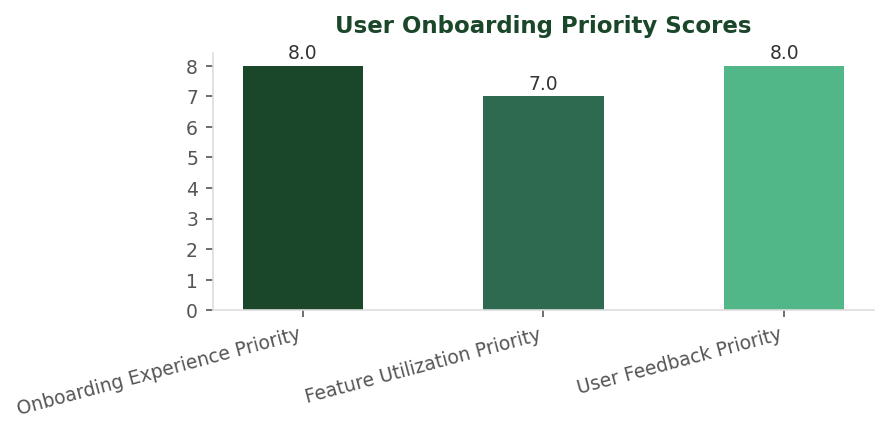
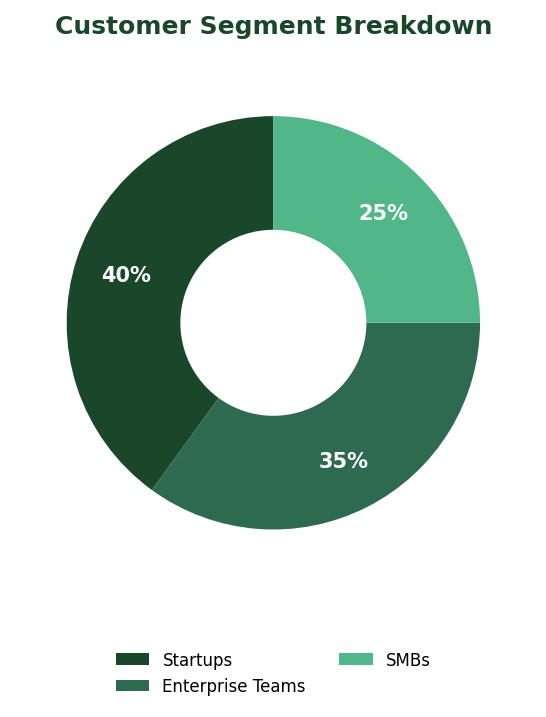
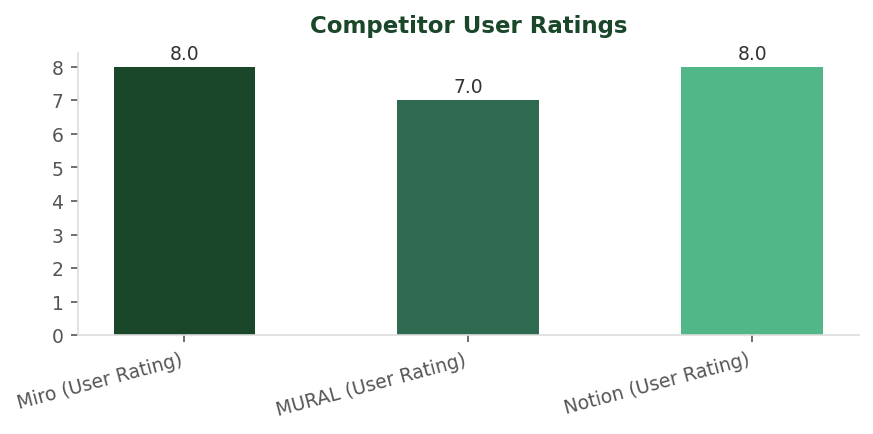
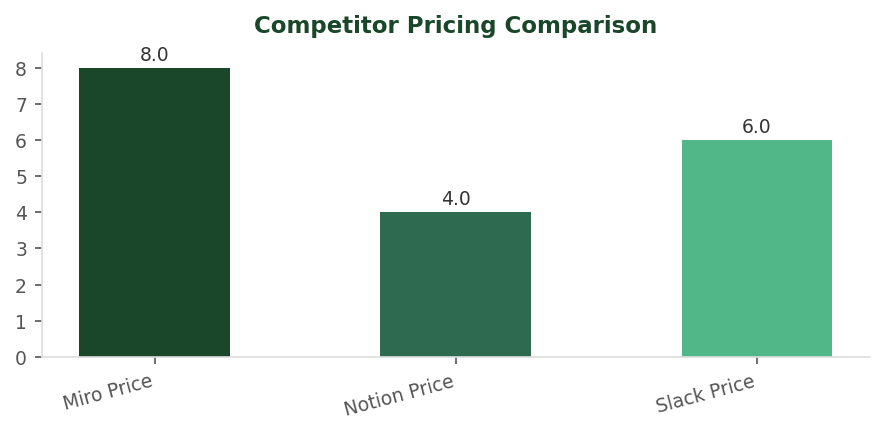
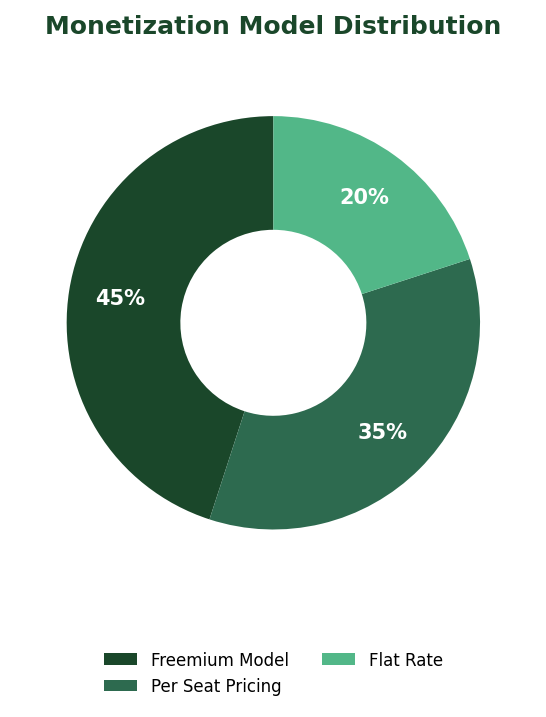
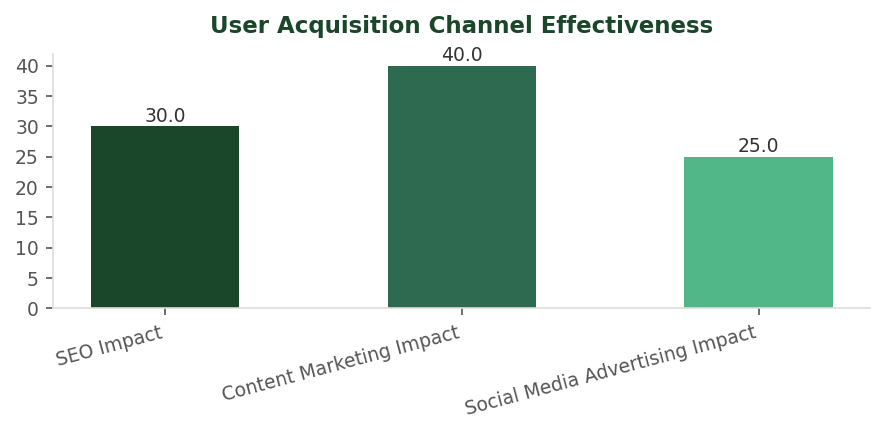

In [18]:
from backend.render_charts import inject_charts, image_to_base64,inject_page_break_css, html_to_pdf, inject_font_html, inject_background
from backend.Agents.PDF_create import Agent1Output, Agent2Output
from langchain_core.messages import AIMessage, HumanMessage
from langchain_openai import ChatOpenAI
import base64
import re


new_state12={
    'Agent1Output' : c
    }

def inject_font_html(html, font_path: str) -> str:
    with open(font_path, 'rb') as f:
        font_b64=base64.b64encode(f.read()).decode('utf-8')

    font_face = f"""
    <style>
      @font-face {{
        font-family: 'Inter';
        src: url('data:font/truetype;base64,{font_b64}');
      }}
    </style>"""

    html = html.replace("</head>", f"{font_face}</head>")
    return html


def Agent2(state):
    agent1_output=state['Agent1Output']

    print(type(agent1_output))  # check what type it actually is
    print(isinstance(agent1_output, dict))

    if isinstance(agent1_output, dict):
        agent1_output = Agent1Output.model_validate(agent1_output)
    elif isinstance(agent1_output, str):
        agent1_output = Agent1Output.model_validate_json(agent1_output)
        
    instruction = """
You are a Report Generation Agent.

Your task is to convert structured insights (JSON input) into a professional, visually rich HTML report.

---

COLOR SCHEME — STRICT, DO NOT DEVIATE:

Use ONLY these colors throughout the entire document:
- Primary dark green:  #1a472a  (headings, section titles, header background)
- Mid green:           #2d6a4f  (subheadings, borders, accents)
- Light green:         #52b788  (highlights, badges, bullet markers)
- Pale green:          #95d5b2  (backgrounds of cards, subtle fills)
- White:               #ffffff  (main content background)
- Dark text:           #333333  (body text)
- Muted text:          #666666  (secondary text, labels)

DO NOT use blue, purple, red, or any other color family.
ALL h1, h2, h3 tags must use color: #1a472a — never blue.

---

BACKGROUND IMAGE — CRITICAL:

The body must have this EXACT CSS:

  body {{
      background-image: BG_IMAGE_PLACEHOLDER;
      background-size: cover;
      background-repeat: no-repeat;
      background-attachment: fixed;
  }}

Also add a position:fixed full-page div as the very first element inside <body>:

  <div style="position:fixed;top:0;left:0;width:100%;height:100%;
              background-image:BG_IMAGE_PLACEHOLDER;
              background-size:cover;background-repeat:no-repeat;z-index:-1;"></div>

Keep BG_IMAGE_PLACEHOLDER exactly as written — DO NOT replace it.

---

CHART PLACEHOLDERS — MANDATORY:

For every insight that has a visualization, you MUST insert a placeholder in this EXACT format:

  <div class="chart-container">[Insert CHART_TYPE: CHART_TITLE]</div>

Where CHART_TYPE and CHART_TITLE come directly from the insight's visualization field.

Example:
  If visualization = {{"type": "bar_chart", "title": "Risk Severity Comparison"}}
  You must write: <div class="chart-container">[Insert bar_chart: Risk Severity Comparison]</div>

Rules:
- Place the placeholder IMMEDIATELY after the insight text it belongs to
- Use the EXACT title from the visualization field — do not paraphrase it
- Do NOT skip any insight that has a visualization
- Do NOT write placeholder text like "chart here" — use the exact format above

---

LAYOUT AND STYLING:

Structure:
- A dark green header (#1a472a) with white title text and the date
- Leave 80px padding at top and 220px padding at bottom (for background wave design)
- Side padding: 50px left and right
- Each section in a white semi-transparent card: background: rgba(255,255,255,0.93)
- Section headings (h2) in #1a472a with a 4px left border in #52b788
- Bullet points using color #52b788 markers
- High importance insights get a left border: border-left: 3px solid #52b788
- Medium importance insights get a left border: border-left: 3px solid #95d5b2

Chart container styling:
  .chart-container {{
      background: rgba(248, 255, 252, 0.9);
      border: 1px solid #95d5b2;
      border-radius: 8px;
      padding: 12px;
      margin: 12px 0;
  }}

---

CONTENT SECTIONS (in this order):
1. Executive Summary
2. Business Insights
3. Market Insights
4. Technical Insights
5. Risks
6. Customer Insights
7. Rival Companies
8. Monetization Strategy
9. Growth Strategy
10. Action Plan
11. Priority Signals
12. Open Questions
13. Knowledge Gaps

---

OUTPUT RULES:
- Return ONLY valid HTML starting with <!DOCTYPE html>
- DO NOT wrap in markdown code fences
- DO NOT add explanations
- DO NOT hallucinate new information
- Use BG_IMAGE_PLACEHOLDER exactly as written — never replace it

---
"""
    ai_message=f"""

INPUT JSON:
{agent1_output}
    """
    
    llm = ChatOpenAI(model='gpt-4o-mini')
    structured_llm = llm.with_structured_output(Agent2Output)
    response = structured_llm.invoke([HumanMessage(content=instruction), AIMessage(content=ai_message)])

    html = response.html

    html = re.sub(r'<link[^>]+fonts\.googleapis\.com[^>]*>', '', html)
    html = re.sub(r'@import url\([^)]*fonts[^)]*\);?', '', html)


    html = inject_charts(html, agent1_output)


    html = inject_page_break_css(html)

    image_b64 = image_to_base64('./pdf_image.png')
    html = inject_background(html, image_b64)

    html = inject_font_html(html, font_path='./Helvetica.ttf')

    html_to_pdf(html, output_path='./PDF/report.pdf')
    return {
        "pdf_html": html,
        "messages": [AIMessage(content="Report generated successfully.")]
    }
b=Agent2(new_state12)
print(b)

In [ ]:
b.get('pdf_html')

NameError: name 'b' is not defined